# Введение

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> Брифинг <a class="tocSkip"></a></h3>
    
**Тестовое задание НИР-Центр на позицию специалист ML**

Задача выглядит следующим образом:
1. Загрузить несколько документов с нормативами о пожарной безопасности с сайта meganorm.ru. 
2. Разработать программу на основе методов анализа текста, которая бы извлекала из этих документов нормативы, то есть, конкретные указания на требования.

**Пример конкретных требований из другого нормативного акта:**

"Точность определения взаимного положения этих пунктов по каждой из трех пространственных координат характеризуется средними квадратическими ошибками 0,25...0,80 м при расстояниях от 500 до 9000 км."
Нас интересует исходный текст требования: обычно одно-два предложения.

**Ограничения:**

1. Решение не должно зависеть от языковых моделей, которые нельзя развернуть локально. 
2. Решение может быть неидеальным, но должны быть предложены пути устранения ошибок и дальнейшего его развития.
3. Можно предложить любой алгоритм, но приминение LLM или предложение развития решения с приминением LLM будет плбсом.

**Результат:**

Ожидаем решение в течение 2 недель

**Дополненительно:**

С учетом комментариев команды НИР-Центр продолжу выполнение тестового задания с использованием алгоритмов машинного обучения. Буду решать задачу классификации текста по аналогии работы спам фильтра. Обязательно использую алгоритм наивного байесовского классификатора для многомерно-распределенных данных и некоторые другие алгоритмы.

--- 

**Ход решения:**

При выполнении тестового задания я буду использовать следующие критерии:
- ООП;
- низкая задержка;
- чистый и понятный код, никаких магических команд;
- легкие и быстрые библиотеки;
- локальная работа без утечки данных и применения API;
- подробные Google-style docstrings с описанием атрибутов и типов.

---

**План:**

- Этап 9. Исследовательский анализ данных;
- Этап 10. Подготовка к обучению;
- Этап 11. Обучение;
- Этап 11. Тестировние;
- Этап 12. Проблемы и возможное развитие;
- Этап 13. Заключение.

</div>

# Исследовательский анализ данных

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Exploratory Data Analysis - является важным этапом, который позволяет лучше понять данные и выявить основные характеристики, распределение и закономерности. На этом этапе я выполню следующее:

- загрузка данных;
- ручная валидация;
- новые признаки;
- статистический анализ;
- визуализация;
- корреляционный анализ;
- отбор признаков для обучения.

</div>

## Загрузка данных

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

При формировании данных для обучения использую результат экстрактора требований, созданный в **Этап 1. ООП.** Выгружу кандидатов с 4 ресурсов.

</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import sys
import os
import re
import random
from collections import Counter
from sklearn.metrics import (
    fbeta_score, 
    make_scorer,
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    RepeatedStratifiedKFold
)
from sklearn.feature_extraction.text import (
    TfidfVectorizer, 
    CountVectorizer
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack
from scipy.stats import spearmanr
import optuna
from phik import phik_matrix
from lightgbm import LGBMClassifier
from colorama import Fore, Style
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display
from natasha import (
    Segmenter, 
    MorphVocab, 
    NewsEmbedding, 
    NewsMorphTagger, 
    Doc
)
pd.set_option('display.max_column', None)
pd.set_option('display.max_colwidth', 500)
pd.set_option('display.max_row', 60)

sys.path.append(os.path.abspath('..'))
from src.utils.loader import MeganormLoader
from src.core.processor import TextProcessor
from src.core.engine import ScoringEngine
from src.core.orchestrator import NormativeOrchestrator

/home/vitalii/anaconda3/envs/ds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
urls = [
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html',
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/3/gost_30403-2012_mezhgosudarstvennyy_standart_konstruktsii.html',
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/4/gost_31251-2008_mezhgosudarstvennyy_standart_steny_naruzhnye.html',
    'https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html'
]

orchestrator = NormativeOrchestrator(
    MeganormLoader(),
    TextProcessor(),
    ScoringEngine()
)

results = []

for url in urls:
    df = orchestrator.run_pipeline(url)
    if not df.empty:
        results.append(df)
        print(f'[INFO] Обработан: {df["document"].iloc[0]}')

data_no_target = pd.concat(results, ignore_index=True)
print(f'[INFO] Сборка завершена, всего извлечено требований: {len(data_no_target)}\n')
display(data_no_target.sample(5))

Error occurred during getting browser(s): random, but was suppressed with fallback.


[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html
[INFO] Обработан: ГОСТ 34714-2021
[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/3/gost_30403-2012_mezhgosudarstvennyy_standart_konstruktsii.html
[INFO] Обработан: ГОСТ 30403-96
[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/4/gost_31251-2008_mezhgosudarstvennyy_standart_steny_naruzhnye.html
[INFO] Обработан: ГОСТ 31251-2003
[INFO] Запрос к https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html
[INFO] Обработан: ГОСТ 12
[INFO] Сборка завершена, всего извлечено требований: 413



,document,text,score,has_metrics,source_url
287,ГОСТ 12,"Статистические данные показывают, что за анализируемый период времени наблюдался один случай разрушения деталей поршневой группы, в результате чего в цилиндре компрессора в течение 2 мин наблюдалось искрение.",3.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html
87,ГОСТ 34714-2021,"Каждый образец раствора должен быть помещен в пластиковую емкость с крышкой, промаркирован и тщательно перемешан, например с использованием магнитной мешалки.",2.0,False,https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html
269,ГОСТ 12,"Влияние начальной герметизации аппарата Для полых аппаратов объемом до 200 м3 с начально открытыми сбросными сечениями, например люками, значение фактора турбулизации не превышает = 2, для аппаратов с начально закрытыми сбросными сечениями (мембраны, разгерметизаторы и т.д.) не превышает = 8.",3.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html
274,ГОСТ 12,"Эффект интенсификации горения в сосуде при сбросе газов через трубопровод исчезает при увеличении давления разгерметизации до 0,2 МПа при начальном давлении 0,1 МПа.",3.0,True,https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html
350,ГОСТ 12,"Расчеты экономического эффекта могут использоваться при определении цен на научно-техническую продукцию противопожарного назначения, а также для обоснования выбора мероприятий по обеспечению пожарной безопасности при формировании планов научно-исследовательских и опытно-конструкторских работ, экономического и социального развития объектов.",2.0,False,https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/5/gost_12_1_004-91_mezhgosudarstvennyy_standart_sistema.html


In [3]:
data_no_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   document     413 non-null    object 
 1   text         413 non-null    object 
 2   score        413 non-null    float64
 3   has_metrics  413 non-null    bool   
 4   source_url   413 non-null    object 
dtypes: bool(1), float64(1), object(3)
memory usage: 13.4+ KB


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Составлю признаковое описание данных:

- document: (str). Название документа или норматива;
- text: (str). Кандидаты в требования;
- score: (float). Оценка релевантности кандидата. Она сформирована на основе черного списка, модальности, наличия физических величин, бонуса за допуски и слишком длинного или короткого кандидата;
- has_metrics: (bool). Флаг наличия физических величин, допусков и единиц измерения;
- source_url: (str). Ссылка на документ.

Ниже сохраню данные для ручной валидации.

</div>

In [4]:
#data_no_target['text'].to_csv('../data/processed/requirements_no_target.csv', index=True, encoding='utf-8-sig')

## Ручная валидация

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

На этом этапе я просмотрел всех кандидатов и определил настоящие требования. Далее создаю столбец `target`, где реальные получат метку 1, все остальные строки получат метку 0.

</div>

In [5]:
val_requirements = [
    0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 18, 19, 20, 21,
    22, 23, 24, 25, 26, 27, 30, 31, 36, 37, 38, 39, 41, 42, 45, 48, 49, 50, 
    52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 66, 68, 69, 70, 71, 72, 
    73, 83, 90, 91, 92, 93, 95, 96, 97, 98, 99, 101, 102, 104, 105, 107, 
    108, 109, 111, 112, 114, 116, 117, 121, 126, 128, 131, 132, 133, 134, 136, 143, 
    145, 147, 148, 149, 150, 151, 152, 153, 155, 156, 157, 160, 161, 163, 166, 
    167, 174, 180, 182, 183, 185, 186, 188, 189, 190, 195, 197, 199, 207, 208, 209, 210, 
    211, 221, 222, 224, 226, 242, 276, 302, 306, 311, 324, 329, 334, 357, 366, 371, 385, 388, 
    393
]
data = data_no_target.copy()
data['target'] = np.where(data.index.isin(val_requirements), 1, 0)

In [6]:
# data.to_csv('../data/processed/data.csv', index=False, encoding='utf-8-sig')
display(data[['text', 'score', 'target']].sample(10))

,text,score,target
179,Общие требования и номенклатура видов защиты ГОСТ 12.1.033-81 Система стандартов безопасности труда.,3.0,0
278,"Влияние степени негерметичности аппарата Увеличение степени негерметичности в 10 раз (от 0,025 до 0,25), что равнозначно увеличению площади разгерметизации в 10 раз для одного и того же аппарата, приводит к возрастанию фактора турбулизации в 2 раза (для аппаратов объемом около 10 м3 с до ).",3.0,0
49,"7.6.2 Вид испытательной среды и испытательное давление устанавливают в зависимости от рабочей среды арматуры: - для арматуры, которая по условиям эксплуатации находится под давлением воды, испытательная среда - вода, испытательное давление P исп = 1,1 P р ; - для арматуры, которая по условиям эксплуатации находится под давлением пенообразователя, испытательная среда - вода, испытательное давление P исп = 1,1 P ПО , где P ПО - давление в линии подачи пенообразователя в дежурном режиме; - для ...",2.5,1
2,"4.2.3 Параметры сигналов автоматического пуска должны соответствовать значениям, установленным изготовителем и указанным в ТД.",5.0,1
322,"Для обеспечения эвакуации необходимо: установить количество, размеры и соответствующее конструктивное исполнение эвакуационных путей и выходов; обеспечить возможность беспрепятственного движения людей по эвакуационным путям; организовать при необходимости управление движением людей по эвакуационным путям (световые указатели, звуковое и речевое оповещение и т.п.).",2.0,0
290,Аппарат имеет рубашку обогрева (80 °C).,3.0,0
73,"Запорные устройства должны быть снабжены указателями (стрелками) и надписями, обозначающими их положение (""Открыто"" - ""Закрыто"") или указывающими на включаемые/выключаемые режимы.",2.0,1
311,При отсутствии сведений о параметрах надежности анализируемого оборудования (изделия) последние определяют расчетным путем на основе статистических данных об отказах этого оборудования (изделия).,2.0,1
272,"Так, увеличение с целью снизить давление взрыва площади разгерметизации в 10 раз в сосуде объемом порядка 10 м3 сопровождается увеличением фактора турбулизации в 2 раза.",3.0,0
214,Акт калибровки испытательной установки вместе с видео- и фотоматериалами калибровки должен быть заверен руководителем испытательной лаборатории и предъявляться заказчику испытаний и представителям надзорных органов по их требованию.,2.0,0



Истинные требования - 138
Другие предложения - 275
Баланс классов 33%



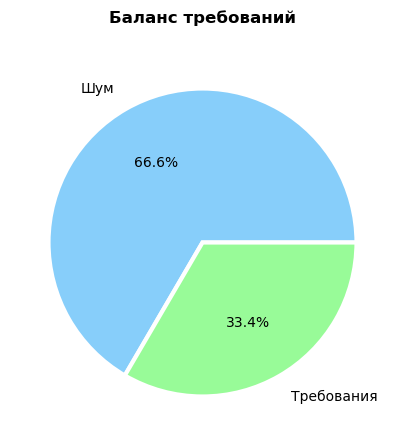

In [7]:
print(f'\nИстинные требования - {data["target"].sum()}')
print(f'Другие предложения - {data.shape[0] - data["target"].sum()}')
print(f'Баланс классов {data["target"].sum() / data.shape[0]:.0%}\n')

# Диаграмма распределения
plt.rcParams['figure.figsize'] = (25, 5)
fig, ax = plt.subplots()
ax.pie(data.target.value_counts(),
       labels=('Шум', 'Требования'),
       autopct='%1.1f%%', labeldistance=1.15,
       wedgeprops = {'linewidth': 3, 'edgecolor': 'white'},
       colors=['lightskyblue', 'palegreen'])
plt.title('Баланс требований', fontsize=12, pad=20, fontweight='bold')
plt.show()

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>
    
По итогу получен датафрейм для дальнейшего анализа и обучения. Присутствует разница в сторону миноритарного класса примерно 1 к 3, что является умеренным дисбалансом. Ниже дополню признаковое описание:

- target: (int). Целевая переменная.

</div>

## Новые признаки

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Замечу важную особенность. В предыдущем этапе **Этап 1. ООП** я генерировал признаки `score` и `has_metric`. Они будут достаточно полезными для создания новых синтетияеских в дальнейшем.

Для повышения обобщающей способности, уменьшения переобучения и лучшего понимания структуры данных математическими алгоритмами разделю создание новых признаков на группы:

- общие;
- для Multinomial Naive Bayes;
- для Logistic Regression;
- для LGBM / HistGradientBoosting.

</div>

### Общие

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Эти признаки извлекаются один раз и подаются во все алгоритмы, кроме Multinomial Naive Bayes. Ниже дополню признаковое описание.

Морфология через natasha и regex:

- modal: (bool). Наличие лемм должный, следует, необходимо, допускаться, запрещаться, необходимо, менее, более, предел, погрешность;
- inf_count: (int). Количество глаголов в инфинитиве;
- verb_count: (int) Общее количество глаголов, маркер действия;
- genitive_ratio: (float). Доля существительных в родительном падеже.

Структура и пунктуация:

- cap_start: (bool). Начинается ли предложение с заглавной буквы;
- ends_dot: (bool). Заканчивается ли точкой;
- ends_semi: (bool). Заканчивается ли точкой с запятой, элемент списка;
- list_marker: (bool). Наличие в начале цифр или букв со скобкой (1., а));
- text_len: (int). Длина предложения в символах;
- digit_density: (float). Доля цифр в тексте, ссылки на параметры;
- all_caps: (bool). Весь текст капсом, признак заголовка;
- lemma_text: (str). Лемматизированные токены через пробел.

</div>

In [8]:
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

MODAL_LEMMAS = {
    'должный', 'следовать', 'необходимо', 'допускаться', 'запрещаться',
    'менее', 'более', 'предел', 'погрешность'
}

def extract_features_batch(texts: list[str | None]) -> list[tuple]:
    '''
    Извлекает морфологические и синтаксические признаки из списка текстов.

    Args:
        list: Список строк для обработки.
    
    Returns:
        list: Список кортежей с признаками.
    '''
    results = []
    
    for text in texts:
        t_s = text.strip()
        doc = Doc(t_s)
        doc.segment(segmenter)
        doc.tag_morph(morph_tagger)

        lemma_text = []
        modal = 0
        inf_count = 0
        verb_count = 0
        n_nouns = 0
        n_gen_nouns = 0
        
        # Один проход по токенам для максимальной скорости
        for t in doc.tokens:
            # Лемматизированные токены
            t.lemmatize(morph_vocab)
            lemma_text.append(t.lemma)

            # Наличие лемм долженствования
            if t.lemma in MODAL_LEMMAS:
                modal = 1

            # Общее количество глаголов
            if t.pos in ('VERB', 'AUX'):
                verb_count += 1
                # Количество глаголов в инфинитиве
                if t.feats.get('VerbForm') == 'Inf':
                    inf_count += 1
            # Существительные в родительном падеже
            elif t.pos == 'NOUN':
                n_nouns += 1
                if t.feats.get('Case') == 'Gen':
                    n_gen_nouns += 1

        text_len = len(t_s)
        
        results.append({
            # Лемматизированные токены
            'lemma_text': ' '.join(lemma_text),
            # Наличие лемм долженствования
            'modal': modal,
            # Количество глаголов в инфинитиве
            'inf_count': inf_count,
            # Общее количество глаголов
            'verb_count': verb_count,
            # Доля существительных в родительном падеже
            'genitive_ratio': round(n_gen_nouns / n_nouns, 3) if n_nouns > 0 else 0.0,
            # Предложение с заглавной буквы
            'cap_start': int(t_s[0].isupper()),
            # Заканчивается ли точкой
            'ends_dot': int(t_s.endswith('.')),
            # Заканчивается ли точкой с запятой, элемент списка
            'ends_semi': int(t_s.endswith(';')),
            # Наличие в начале цифр или букв со скобкой
            'list_marker': int(bool(re.match(r'^(\d+\.?|[а-яё]\)|\d+\))', t_s))),
            'text_len': text_len,
            # Доля цифр в тексте
            'digit_density': round(sum(c.isdigit() for c in t_s) / text_len, 2) if text_len > 0 else 0.0,
            # Весь текст капсом
            'all_caps': int(t_s.isupper() and text_len > 5)
        })
        
    return results

In [9]:
cols = [
    'lemma_text', 'modal', 'inf_count', 'verb_count', 'genitive_ratio', 'cap_start', 
    'ends_dot', 'ends_semi', 'list_marker', 'text_len', 'digit_density', 
    'all_caps'
]

batch_results = extract_features_batch(data['text'].tolist())
data = pd.concat([data, pd.DataFrame(batch_results)], axis=1)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Постепенно собираю мастер-датасет, что получил здесь:

- синтаксическая сложность. Добавил `digit_density`, в требованиях ГОСТа нагромождение существительных в родительном падеже (контроль качества поверхности изделия) — это добротный сигнал;
- очистка для векторов. `lemma_text` теперь содержит только значимые слова. Это критично для Multinomial Naive Bayes, чтобы он не учился на предлогах и запятых.

</div>

### Multinomial Naive Bayes

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Алгоритм работает с вероятностями токенов, поэтому признак я сделаю текстом и добавлю различные ключевые токены словами:

- MODAL. 
- NO_VERB, 
- CAP_START,
- ENDS_DOT,
- LIST_MARKER_SEMI,
- ALL_CAPS,
- TOKEN_SHORT.
- SCORE_LOW,
- SCORE_MEDIUM,
- SCORE_HIGH.

Ниже дополню признаковое описание.

- text_mnb: (str). Гибридный текст включает в себя лемматизированный и набор токенов.

</div>

In [10]:
def text_go_mnb(df: pd.DataFrame) -> pd.Series:
    '''Создает гибридный текст для MNB из подмножества признаков.
    
    Args:
        df (pd.DataFrame): Датасет, из него только необходимые признаки.

    Return:
        pd.Series: Обогащенный текст.
    '''

    req_cols = [
        'lemma_text', 'modal', 'verb_count', 'cap_start', 
        'ends_dot', 'all_caps', 'text_len', 
        'list_marker', 'ends_semi', 'score'
    ]
    
    d = df[req_cols].copy()
    res = d['lemma_text'].fillna('').astype(str)

    # Быстрые векторные операции через NumPy
    # добавляю токен с пробелом, чтобы не сливался текст
    res += np.where(d['modal'] == 1, ' MODAL', '')
    res += np.where(d['verb_count'] == 0, ' NO_VERB', '')
    res += np.where(d['cap_start'] == 1, ' CAP_START', '')
    res += np.where(d['ends_dot'] == 1, ' ENDS_DOT', '')
    res += np.where(d['all_caps'] == 1, ' ALL_CAPS', '')
    res += np.where(d['text_len'] < 35, ' TOKEN_SHORT', '')
    
    list_semi = (d['list_marker'] == 1) | (d['ends_semi'] == 1)
    res += np.where(list_semi, ' LIST_MARKER_SEMI', '')

    # Дискретизация score, а labels с пробела, чтобы текст не слипался
    score_tokens = pd.cut(
        d['score'], 
        bins=[-np.inf, 2.0, 3.5, np.inf], 
        labels=[' SCORE_LOW', ' SCORE_MEDIUM', ' SCORE_HIGH'],
        right=False
    ).astype(str)
    
    res += score_tokens

    return res.str.strip()


In [11]:
data['text_mnb'] = text_go_mnb(data)

In [12]:
display(data[['text_mnb', 'target']].sample(5))

,text_mnb,target
100,определение кратность пена проводить один из следующий способ : - взвешивание образец пена ( 7.11.2.1 ) ; - взвешивание образец пена и раствор ( 7.11.2.2 ) ; - измерение объем выпадать раствор ( 7.11.2.3 ) . CAP_START ENDS_DOT SCORE_MEDIUM,0
229,"отсюда нетрудный вычислить , что диаметр предохранительный мембрана должный быть равный 0,5 м . MODAL CAP_START ENDS_DOT SCORE_HIGH",0
134,"материал и деталь образец , подлежать испытание , в тот число стыковой соединение ограждать конструкция , должный соответствовать технический документация на они изготовление и применение . MODAL CAP_START ENDS_DOT SCORE_MEDIUM",1
363,экономический эффект затрата на обеспечение пожарный безопасность определяться по результат эксплуатация за расчетный период . CAP_START ENDS_DOT SCORE_MEDIUM,0
403,"коэффициент расход коэффициент расход являться эмпирический коэффициент , учитывать влияние реальный условие истечение на величина расход газ , определить по известный теоретический модельный соотношение . CAP_START ENDS_DOT SCORE_MEDIUM",0


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>
    
Вот он чистый и понятный подход. Дополнил мастер-датасет жирным признаком `text_mnb`. Теперь алгоритм Байеса получит мощные паттерны в виде токенов.

</div>

### Logistic Regression

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>
    
Статистический алгоритм отлично пережевывает линейные зависимости, но чувствителен к масштабу. Поэтому обязательно выполню стандартизацию, тобиш центрирую данные, чтобы среднее стало 0. Но прежде фильтрую выбросы и аномалии. И тогда признаки из раздела **Общие** подклею к матрице. Сама суть подготовки признаков к обучению заключается в следующем:

- текстовое ядро. TF-IDF на леммах, униграммы и биграммы;
- объенение остальных признаков с текстовым ядром.

Все это я выполню в **Этап 10. Подготовка к обучению**. Дополнительно проверю мультиколлинеарность, так как логистическая регрессия может выдавать нестабильные веса из-за этого. И исключу ее при необходимости. 

Ниже дополню признаковое описание.

- tfidf_logreg: (float). Гибридный текст включает в себя векторизированный текст и стандартизированные признаки.

</div>

### LGBM / HistGradientBoosting

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Алгоритмы на деревьях отлично усваивают нелинейные признаки и категории. Для них подготовка будет похожа на LogReg, но с ключевыми отличиями. Деревянные алгоритмы плохо работают с разреженными матрицами из 10 000 колонок TF-IDF, поэтому использую спец эмбеддинги или хитрое сжатие. Дополню признаковое описание:

- navec_tree: (float). Средний эмбеддинг Navec в 300 колонок от natasha; 
- или svd_tree: (float). Сжатый через TruncatedSVD признак TF-IDF до 50–100 умных колонок.

Описанные выше действия выполню в **Этап 10. Подготовка к обучению**. Так как векторизацию текста необходимо делать после разделения на train и test для исключения утечки информации в тестовую выборку.

</div>

## Визуализация

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Визуально посмотю, как выглядят признаки `text_len` и `digit_density`.

</div>

In [13]:
def hist_box_num_sub(categ, data, bins, x, hue, title_hist, xlabel, ylabel, factor_vline, **kwargs):
    """
    categ - уникальные значения из любого категориального признака, по количеству которых будут определены цвета
    data - датафрейм
    bins - количество корзин
    x - ость, по которой распределяются значения количественного признака
    hue - семантическая переменная, которая сопоставляется для определения цвета элементов графика.
    title_hist - название гистограммы
    xlabel, ylabel - название осей
    factor_vline - множитель для средней и медианы
    **kwargs:
     - rotation=90 - угол поворота надписей по оси х
     - fig_size=(17, 4) - размер графиков
     - x_range=(0, 30) - ограничение диапазона по оси х
     - y_range=(0, 30) - ограничение диапазона по оси y
    Переменные categ и hue должны совпадать по количеству уникальных значений, так как палитра цветов строится на основе этого значения 
    """
    # Случайные цвета
    def random_color():
        return '#{:06x}'.format(random.randint(0, 0xFFFFFF))

    # Уникальные категории
    categories = categ

    # Случайные цвета для каждой категории
    colors_hist = {cat: random_color() for cat in categories}
    colors_box = {cat: random_color() for cat in categories}
	
	# Вертикальные линии
    mean = np.mean(data[x])
    median = np.median(data[x])
    
    # Инициализация объекта Figure и создание подграфиков
    fig_size = kwargs['fig_size'] if 'fig_size' in kwargs else (10, 10)
    fig, axes = plt.subplots(2, 1, figsize=fig_size)

    # Установка диапазона по оси x, если задан
    if 'x_range' in kwargs:
        axes[0].set_xlim(kwargs['x_range'])
        axes[1].set_xlim(kwargs['x_range'])
        
    # Установка диапазона по оси Y, если задан
    if 'y_range' in kwargs:
        axes[0].set_ylim(kwargs['y_range'])
        y_max = kwargs['y_range'][1] * factor_vline  # Используем верхнюю границу y_range
    else:
        y_max = axes[0].get_ylim()[1] * factor_vline  # Получаем текущее значение, если y_range не задан
    
    sns.histplot(data=data, 
                 x=x, 
                 bins=bins,
                 hue=hue,
                 palette=colors_hist,
                 ax=axes[0], 
                 kde=True,
                 multiple='stack',
                 legend=True
                )
    
    # Целые числа по оси Y
    axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
    
    axes[0].vlines(mean, 0, y_max, color='red', label='Среднее')
    axes[0].vlines(median, 0, y_max, color='blue', linestyle='--', label='Медиана')
    axes[0].set_title(title_hist,  fontsize=9)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(ylabel)
    
    sns.boxplot(data=data, 
                x=x, 
                hue=hue,
                palette=colors_box,
                ax=axes[1]
               )
    axes[1].set_title('Ящик с усами количественного признака',  fontsize=9)
    axes[1].set_xlabel(xlabel)
    axes[1].legend(title=hue, loc='upper left')
    plt.tight_layout()
    plt.show()

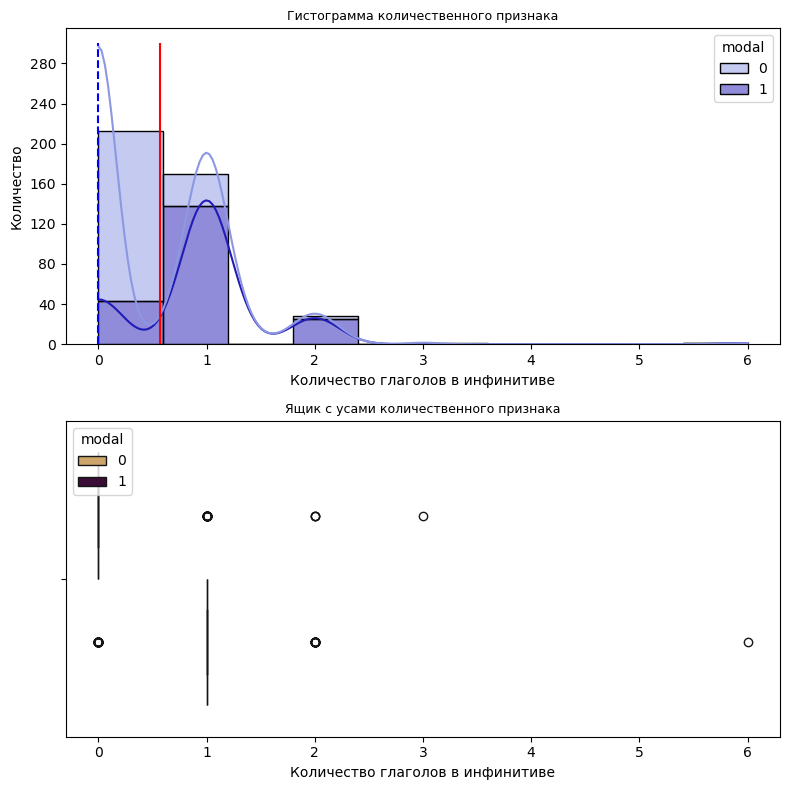

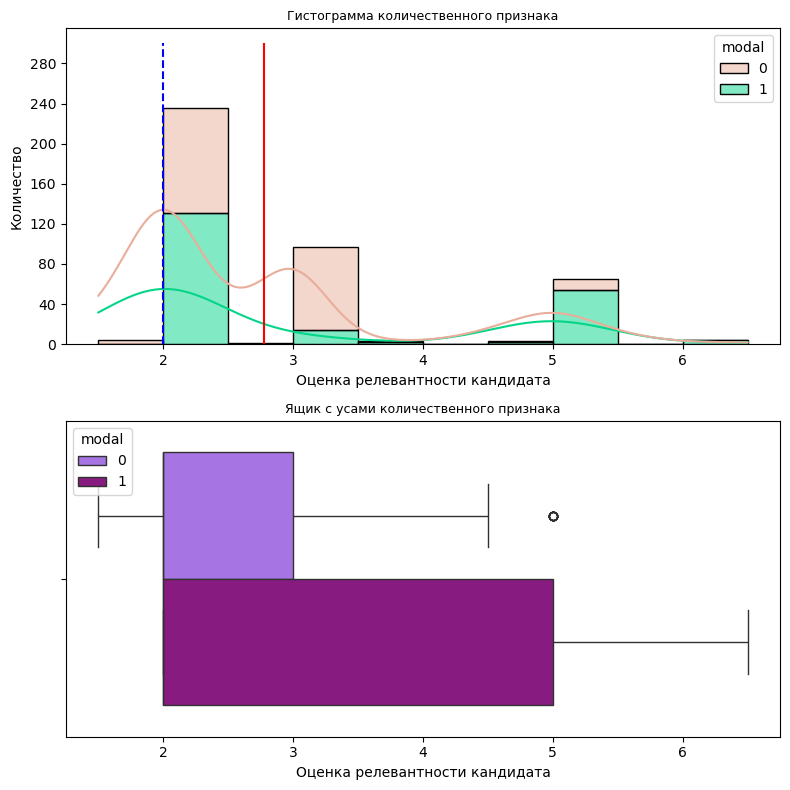

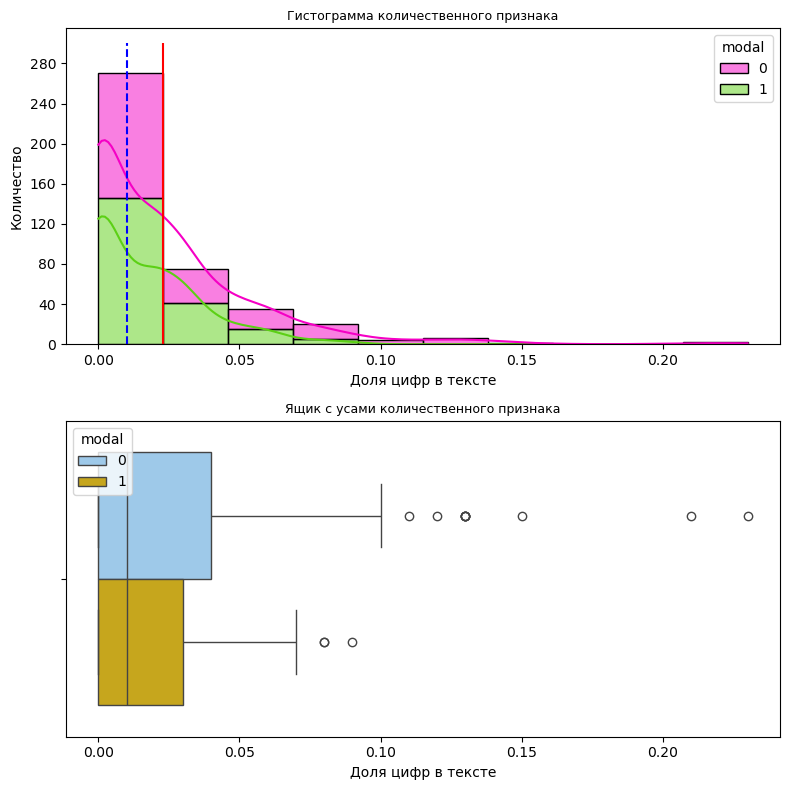

In [14]:
name_for = {
    'inf_count': 'Количество глаголов в инфинитиве',
    'score': 'Оценка релевантности кандидата',
    'digit_density': 'Доля цифр в тексте'
}
for key, value in name_for.items():
    hist_box_num_sub(
    data.modal.unique(),
    data, 
    10,
    key, 
    'modal',
    'Гистограмма количественного признака', 
    value, 
    'Количество',
    300,
    fig_size=(8, 8)
)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Есть выбросы, плотнее поработаю с ними на **Этап 10. Подготовка к обучению**.

</div>

## Статистический анализ

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

В данном разделе посмотрю следующие моменты. Это поможет понять природу синтетических признаков:

- какие уникальные значения есть в признаках;
- посмотрю распределение числовых признаков;
- проверю статистическую значимость p-value.

</div>

### Уникальные значения

In [15]:
def check_types(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Сводная таблица с типами и уникальными значениями всех признаков.
    '''
    type_info = []
    
    for col in data.columns:
        type_info.append({
            'Тип': df[col].dtype,
            'Признак': col,
            'Уникальных значений': df[col].nunique(),
            'Пример': df[col].iloc[0] if len(df) > 0 else 'No data'
        })
    
    df_info = pd.DataFrame(type_info).set_index('Признак')
    return df_info

check_types(data)

,Тип,Уникальных значений,Пример
Признак,,,
document,object,4,ГОСТ 34714-2021
text,object,403,Относительная погрешность измерения времени не должна превышать +/- 10%.
score,float64,8,6.5
has_metrics,bool,2,True
source_url,object,4,https://meganorm.ru/mega_doc/norm/gost_gosudarstvennyj-standart/0/gost_34714-2021_ISO_7076-5-2014_mezhgosudarstvennyy_standart.html
target,int64,2,1
lemma_text,object,403,относительный погрешность измерение время не должный превышать + / - 10 % .
modal,int64,2,1
inf_count,int64,5,1


In [16]:
def type_unique(df: pd.DataFrame, type_cols=None) -> None:
    '''
    Уникальные значения по признакам.
    
    Параметры:
        df - данные,
        type_cols - список признаков, по умолчанию все признаки.
    Result:
        интерактивный вывод.
    '''

    # type_cols в список, если это Index или другой тип
    if type_cols is not None:
        type_cols = list(type_cols)
        
    # Если не передан список признаков - вывод всех признаков
    if type_cols is None:
        type_cols = df.columns.tolist()
        print(
            f'{Style.BRIGHT}{Fore.GREEN}Анализ всех признаков '
            f'({len(type_cols)} колонок):{Style.RESET_ALL}'
        )
    
    # Если передан пустой список
    elif len(type_cols) == 0:
        print(
            f'{Fore.YELLOW}Предупреждение: передан пустой '
            f'список признаков{Style.RESET_ALL}'
        )
        return
    
    # Проверяю, что все переданные признаки существуют в DataFrame
    missing_cols = [col for col in type_cols if col not in df.columns]
    if missing_cols:
        print(
            f'{Fore.RED}Ошибка: следующие признаки отсутствуют '
            f'в данных: {missing_cols}{Style.RESET_ALL}'
        )
        type_cols = [col for col in type_cols if col in df.columns]
    
    if not type_cols:
        print(
            f'{Fore.RED}Ошибка: нет существующих признаков '
            f'для анализа{Style.RESET_ALL}'
        )
        return
    
    print(
        f'{Style.BRIGHT}{Fore.GREEN}Анализ '
        f'{len(type_cols)} признаков:{Style.RESET_ALL}'
    )
    
    for i, col in enumerate(type_cols, 1):
        print(
            f'{Style.BRIGHT}{Fore.CYAN}\n{i}. Уникальные значения '
            f'в колонке "{col}":{Style.RESET_ALL}'
        )
        print(f'Тип данных: {df[col].dtype}')
        print(f'Количество уникальных значений: {df[col].nunique()}')

        value_counts = df[col].value_counts(dropna=False)

        if df[col].nunique() > 20:
            print('Топ-10 самых частых значений:')
            print(value_counts.head(10))
            print(f'... и еще {df[col].nunique() - 10} значений')
        else:
            print(value_counts)

In [17]:
type_unique(data)

Анализ всех признаков (19 колонок):
Анализ 19 признаков:

1. Уникальные значения в колонке "document":
Тип данных: object
Количество уникальных значений: 4
document
ГОСТ 12            198
ГОСТ 34714-2021    112
ГОСТ 31251-2003     64
ГОСТ 30403-96       39
Name: count, dtype: int64

2. Уникальные значения в колонке "text":
Тип данных: object
Количество уникальных значений: 403
Топ-10 самых частых значений:
text
Допустимое расхождение между результатами наиболее отличающихся определений с доверительной вероятностью 0,95 должно быть не более 10% среднего значения.                                                                                                                                                 4
Горизонтальное расстояние между ними должно соответствовать требованиям нормативных документов, но быть не менее 10 м.                                                                                                                                                                       

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Признаки `ends_dot`, `ends_semi` и `all_caps` без полезной нагрузки, их можно не использовать для обучения алгоритмов. Ниже обавлю красок в исследование и посмтрою пузырьковую диаграмму частоты лемм в требованиях.

</div>

In [18]:
def lemma_frequency(
    df: pd.DataFrame, 
    col_name: str = 'lemma_text', 
    top_n: int = 20, 
    min_len: int = 3
) -> None:
    '''Визуализирует частоту лемм в виде пузырьковой диаграммы.

    Аргументы:
        df (pd.DataFrame): Исходный датафрейм.
        col_name (str): Имя колонки с леммами.
        top_n (int): Количество слов для отображения на графике.
        min_len (int): Минимальная длина слова.
    '''
    raw_text = ' '.join(df[col_name].fillna('').astype(str))
    all_lemmas = [w for w in raw_text.split() if len(w) >= min_len]
    
    counts = Counter(all_lemmas).most_common(top_n)
    top_df = pd.DataFrame(counts, columns=['word', 'freq'])
    top_df['rank'] = range(1, len(top_df) + 1)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=top_df, 
        x='rank', 
        y='word', 
        size='freq', 
        hue='word', 
        legend=False, 
        sizes=(100, 2000),
        alpha=0.7
    )

    plt.title(
        f'Топ-{top_n} лемм в требованиях',
        fontsize=15, pad=20, fontweight='bold'
        )
    plt.xticks(range(1, top_n + 1))
    plt.xlabel('Ранг', fontsize=11, fontweight='bold')
    plt.ylabel('Лемма', fontsize=11, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

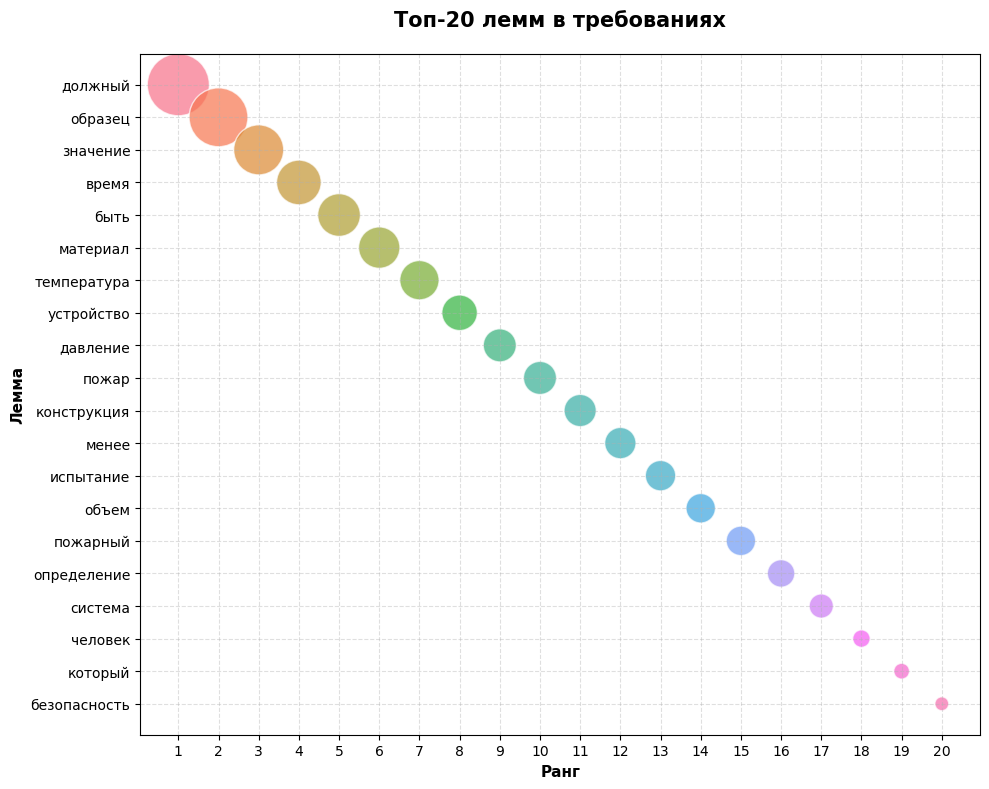

In [19]:
lemma_frequency(data, top_n=20, min_len=4)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Абсолютный чемпион - **должный**. Другие слова из топ-5 не несут уникального смысла, но скорее всего технически необходимы для построения предложений.

</div>

### Распределение числовых признаков

In [20]:
num_cols = [
    'score', 'inf_count', 'verb_count',
    'genitive_ratio', 'digit_density' 
]
for i in num_cols:
    print(
            f'{Style.BRIGHT}{Fore.CYAN}Распределение '
            f'в колонке {i}:{Style.RESET_ALL}'
        )
    display(data[i].describe())

Распределение в колонке score:


count    413.000000
mean       2.776029
std        1.145943
min        1.500000
25%        2.000000
50%        2.000000
75%        3.000000
max        6.500000
Name: score, dtype: float64

Распределение в колонке inf_count:


count    413.000000
mean       0.569007
std        0.684934
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        6.000000
Name: inf_count, dtype: float64

Распределение в колонке verb_count:


count    413.000000
mean       2.070218
std        1.495108
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       12.000000
Name: verb_count, dtype: float64

Распределение в колонке genitive_ratio:


count    413.000000
mean       0.529855
std        0.203044
min        0.000000
25%        0.417000
50%        0.556000
75%        0.667000
max        1.000000
Name: genitive_ratio, dtype: float64

Распределение в колонке digit_density:


count    413.000000
mean       0.022833
std        0.030632
min        0.000000
25%        0.000000
50%        0.010000
75%        0.030000
max        0.230000
Name: digit_density, dtype: float64

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Обращаю внимание на следующие моменты. Распределения говорят о том, что выборка довольно однородная, но в ней есть интересные аномалии.

1. `score`.

Медиана 2.0 ниже среднего 2.77. Это значит, что много текстов с базовым скором, но есть хвост очень высоких значений до 6.5.

Инсайт. Большинство текстов попадает в категорию `SCORE_MEDIUM` 2-3.5, а `SCORE_HIGH` будет довольно редким. Модель MNB скорее всего будет сильно реагировать на этот хвост.

2. `inf_count` и `verb_count`, стиль без глаголов.

`inf_count` - медиана 0. Более 50% текстов вообще не содержат инфинитивов.
`verb_count` - среднее всего 2 глагола на текст. 25% текстов имеют 1 или 0 глаголов.

Инсайт. Синтетический токен `NO_VERB` будет встречаться часто и станет важным маркером структуры.

3. `genitive_ratio`, канцелярский язык.

Среднее 0.53, это очень высокий показатель. В каждом втором существительном используется родительный падеж.

Инсайт. Типичный признак официально-делового или технического стиля. Признак стабильный, низкое стандартное отклонение 0.2, значит тексты выдержаны в одном стиле.

4. `digit_density`.

Медиана 0.01, в среднем 10% символов - это цифры. Это нормально для техзаданий с ГОСТами и параметрами. Максимальное значение до 23%, что само по себе является допустимым показателем.

**Итог.**

`genitive_ratio` и `verb_count` отлично разделят данные, если в мажоритарном классе больше глаголов и меньше канцелярских слов.
Признак `inf_count` слишком разреженный, много нулей. Он может быть бесполезен для классификации большинства строк.

</div>

### Статистическая значимость

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Подробнее рассмотрю, не является ли высокая корреляция случайностью на выборке. Если `p-value < 0.05`, признак честный. Если выше — алгоритм может на нем переобучиться, увидит закономерность там, где её нет.

Проверю с помощью Спирмена по трем причинам:

1. Нелинейность, но монотонность. Пирсон ищет только строгую прямую линию. Спирмен ищет монотонную связь. Например, если с ростом `digit_density` шанс требования растет не пропорционально (1, 2, 4, 8...), а скачками, Пирсон покажет слабую связь, а Спирмен - сильную.
    
2. Тип данных. Мой target - это 0 или 1, а не непрерывное число, как цена квартиры. Пирсон плохо работает, когда одна из переменных имеет всего два значения. Спирмен ранжирует данные, что гораздо корректнее для бинарной классификации.

3. Устойчивость к выбросам. В ГОСТах бывают аномально длинные предложения. Пирсон очень чувствителен к таким выбросам и может выдать ложную корреляцию. Спирмен переводит значения в ранги (1-й по длине, 2-й и т.д.), поэтому один гигантский абзац не сломает всю статистику.

</div>

In [21]:
# Список колонок для анализа
feature_cols = [
    'score', 'has_metrics', 'modal', 'inf_count', 'verb_count', 
    'genitive_ratio', 'cap_start', 'ends_dot', 'ends_semi',
    'list_marker', 'text_len', 'digit_density', 'all_caps'
]

def significance(df: pd.DataFrame, target_col: str, feature_cols: list):
    '''
    Считает корреляцию Спирмена и p-value для всех признаков относительно таргета.
    '''
    
    results = []
    for col in feature_cols:
        if col not in df.columns:
            continue
        
        coef, p_val = spearmanr(df[col], df[target_col])
        
        results.append({
            'Признаки': col,
            'Корреляция': round(coef, 3),
            'p_value': round(p_val, 4),
            'Значимость': 'да' if p_val < 0.05 else 'нет'
        })
    
    # Формируем итоговую таблицу
    stat_df = pd.DataFrame(results).sort_values(by='p_value', ascending=True)
    return stat_df
significance(data, 'target', feature_cols)

,Признаки,Корреляция,p_value,Значимость
2,modal,0.286,0.0000,да
9,list_marker,0.238,0.0000,да
6,cap_start,-0.238,0.0000,да
3,inf_count,0.149,0.0023,да
11,digit_density,0.128,0.0093,да
0,score,0.104,0.0341,да
5,genitive_ratio,-0.073,0.1370,нет
4,verb_count,0.038,0.4383,нет
10,text_len,-0.036,0.4667,нет
12,all_caps,-0.035,0.4794,нет


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> Вывод <a class="tocSkip"></a></h4>

Результаты показывают, что датасет и признаки имеют четкую структуру. Вот краткий разбор:

1. Лидеры.

- `modal` 0.286 и `list_marker` 0.238 - самые сильные предикторы. Модели будут опираться на них в первую очередь;
- `cap_start` -0.238 - очень важный обратный маркер. Отрицательная корреляция подтверждает, если строка начинается с маленькой буквы, шанс, что это самостоятельное требование, падает.
- `inf_count` и `digit_density` - статистически значимы, но их влияние слабее. Это вспомогательные признаки;
- `score` 0.104 - прошел по нижней границе значимости $p < 0.05$. Ручной алгоритм работает, но лингвистические признаки `modal` пока сильнее его.

2. Кандидаты на вылет.

- `verb_count`, `has_metrics`, `all_caps`, `text_len` - на текущей выборке 413 строк, это статистический шум;
- Например, `text_len` -0.036 говорит о том, что длина предложения в ГОСТах почти не влияет на то, является оно требованием или нет;
- для LogReg и MNB эти колонки лучше удалить, чтобы не вносить помехи.

3. Вывод.

Я определил 6 рабочих зацепок. Думаю, этого достаточно для постройки бейслайна, который будет на голову выше простого TF-IDF.

- `modal`
- `list_marker`
- `cap_start`
- `inf_count`
- `digit_density`
- `score`

</div>

## Корреляционный анализ

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

На данном этапе отработаю такую логику. 

1. Корреляция.

Проверю, как каждый признак связан с `target`. Опять же возвращаюсь к корреляции Спирмена. Она идеальна, так как не требует нормального распределения и ловит нелинейные, но монотонные связи.

4. Мультиколлинеарность.

Здесь проверю не дублируют ли признаки друг друга. Построю тепловую карту корреляций между самими признаками. Если `inf_count` и `verb_count` имеют корреляцию 0.95, для LogReg нужно оставить только один из них, чтобы веса модели не взорвались. Для LGBM это менее критично.

</div>

In [22]:
def analyze_phik_correlation(
    df, 
    interval_cols=None,
    fontsize_factor=1.5,
    figsize=(50, 50),
    convert_boolean_cols=True,
    annot=True,
    linewidths=0.5,
    multicoll_threshold=0.95
):
    """
    Полный анализ и визуализация матрицы корреляций phik в одной функции.

    Args:
        df : pandas.DataFrame
            Исходный DataFrame, для которого рассчитывается матрица корреляций phik.
        interval_cols : list, optional
            Список числовых колонок для анализа. Если None, используются все колонки.
        fontsize_factor : float, default=1.5
            Множитель для размера шрифта в heatmap.
        figsize : tuple, default=(50, 50)
            Размер фигуры (ширина, высота) для визуализации heatmap.
        convert_boolean_cols : bool, default=True
            Преобразовывать ли boolean колонки в int перед вычислением корреляции.
        annot : bool, default=True
            Показывать ли значения корреляции в ячейках heatmap.
        linewidths : float, default=0.5
            Ширина линий между ячейками heatmap.
        multicoll_threshold : float, default=0.95
            Порог для определения мультиколлинеарности: если |phik| > threshold,
            пара признаков считается мультиколлинеарной.

    Return: tuple (phik_matrix, multicollinear_df):
            phik_matrix -> pandas.DataFrame. 
            Матрица корреляций phik.
            multicollinear_df -> pandas.DataFrame.
            DataFrame с парами мультиколлинеарных признаков и значением корреляции.
    """
    
    def find_multicollinear_features(corr_matrix, threshold=0.95):
        """
        Находит пары признаков с мультиколлинеарностью выше порога
        """
        multicollinear_pairs = []
        
        # Проход по верхней треугольной матрице без диагонали
        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                corr_value = corr_matrix.iloc[i, j]
                
                # Если корреляция выше порога
                if abs(corr_value) >= threshold:
                    feature1 = corr_matrix.columns[i]
                    feature2 = corr_matrix.columns[j]
                    
                    multicollinear_pairs.append({
                        'Признак 1': feature1,
                        'Признак 2': feature2,
                        'Корреляция': round(corr_value, 4)
                    })
        
        if multicollinear_pairs:
            multicollinear_df = pd.DataFrame(multicollinear_pairs)
            multicollinear_df = multicollinear_df.sort_values('Корреляция', ascending=False)
            multicollinear_df = multicollinear_df.reset_index(drop=True).set_index('Признак 1')
            
            display(multicollinear_df)
            print(f'\n{Style.BRIGHT}{Fore.GREEN}Статистика мультиколлинеарности:{Style.RESET_ALL}')
            print(f'Пар с корреляцией ≥ {threshold}: {len(multicollinear_df)}')
            
            if len(multicollinear_df) > 0:
                print(f'\n{Style.BRIGHT}{Fore.RED}Рекомендации:{Style.RESET_ALL}')
                print('• Рассмотри удаление одного из признаков в каждой паре')
                print('• Используй методы уменьшения размерности (PCA)')
                print('• Примени регуляризацию в моделях машинного обучения')
                
        else:
            multicollinear_df = pd.DataFrame(columns=['Признак 1', 'Признак 2', 'Корреляция'])
            print(f'\n{Style.BRIGHT}{Fore.GREEN}Пар признаков с '
                  f'мультиколлинеарностью ≥ {threshold} '
                  f'не найдено{Style.RESET_ALL}')
        
        return multicollinear_df
    
    df_analysis = df.copy()
    # boolean колонки в int если нужно
    if convert_boolean_cols:
        boolean_cols = df_analysis.select_dtypes(include=['boolean']).columns
        if len(boolean_cols) > 0:
            for col in boolean_cols:
                df_analysis[col] = df_analysis[col].astype(int)
    
    # Если interval_cols не указаны, использую все числовые колонки
    if interval_cols is None:
        interval_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()
        print(f'Автоматически выбраны числовые колонки: {len(interval_cols)} шт.')
    
    print('Вычисление корреляции phik...')
    phik_overview = phik_matrix(
        df_analysis,
        interval_cols=interval_cols
    )
    print(
        f'{Style.BRIGHT}{Fore.CYAN}Размер матрицы: '
        f'{phik_overview.shape}{Style.RESET_ALL}'
    )
    
    plt.figure(figsize=figsize)
    sns.heatmap(
        phik_overview.values, 
        annot=annot, 
        fmt='.2f', 
        cmap='Greens', 
        vmin=0, 
        vmax=1, 
        cbar=False, 
        linewidths=linewidths,
        linecolor='gray',
        xticklabels=phik_overview.columns, 
        yticklabels=phik_overview.index,
        annot_kws={'size': fontsize_factor * 5} 
    )
    plt.yticks(fontsize=fontsize_factor * 5) 
    plt.xticks(fontsize=fontsize_factor * 5)
    plt.title(r'correlation $\phi_K$', fontsize=fontsize_factor * 10)
    plt.tight_layout()
    plt.show()
    
    # Поиск и вывод мультиколлинеарных признаков
    multicollinear_df = find_multicollinear_features(
        phik_overview, 
        threshold=multicoll_threshold
    )
    
    return phik_overview, multicollinear_df

In [23]:
col_analysis = [
 'score',
 'has_metrics',
 'target',
 'modal',
 'inf_count',
 'verb_count',
 'genitive_ratio',
 'cap_start',
 'list_marker',
 'text_len',
 'digit_density'
 ]

Вычисление корреляции phik...
Размер матрицы: (11, 11)


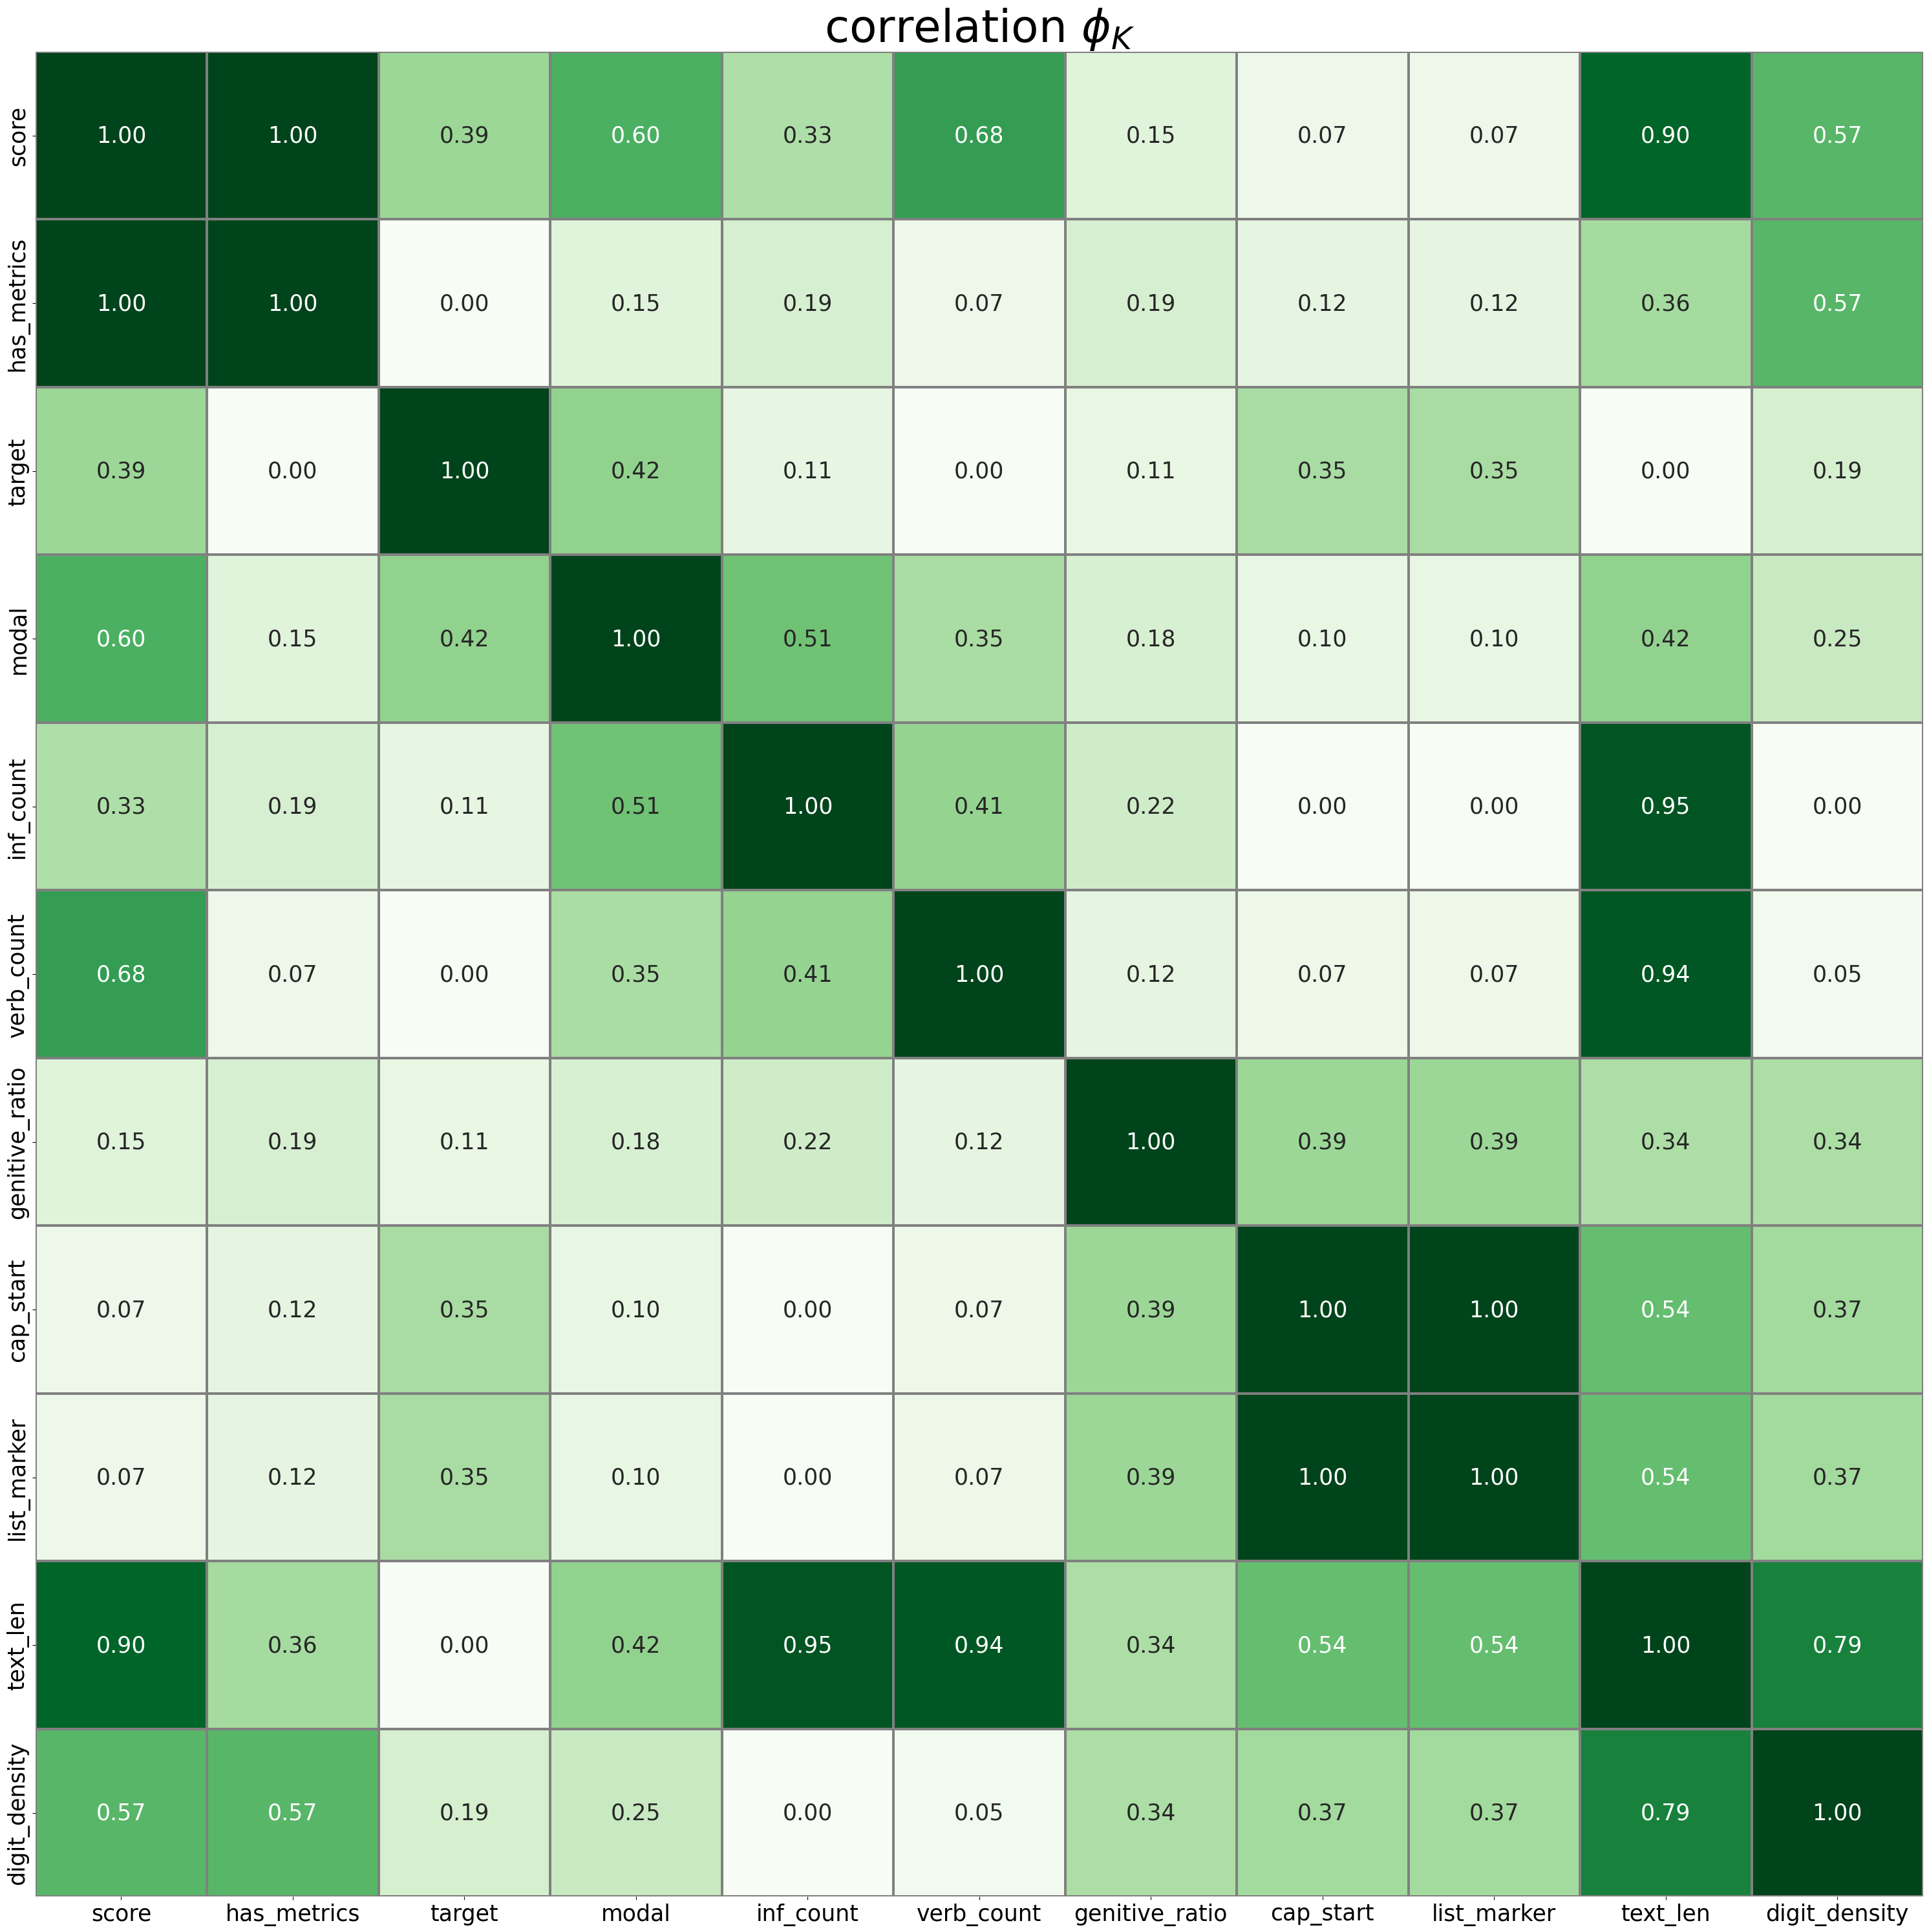

,Признак 2,Корреляция
Признак 1,,
score,has_metrics,1.0000
cap_start,list_marker,0.9999



Статистика мультиколлинеарности:
Пар с корреляцией ≥ 0.95: 2

Рекомендации:
• Рассмотри удаление одного из признаков в каждой паре
• Используй методы уменьшения размерности (PCA)
• Примени регуляризацию в моделях машинного обучения


In [24]:
phik_overview, multicollinear_df = analyze_phik_correlation(
    data[col_analysis], 
    interval_cols=num_cols,
    fontsize_factor=5,
    figsize=(30, 30),
    convert_boolean_cols=True,
    annot=True,
    linewidths=1.5,
    multicoll_threshold=0.95
)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Вот как выглядит реальная структура данных. Эти четыре пары - шпионы, которые дублируют друг друга. Они избыточны и нужно избавляться от мультикорреляции, чтобы алгоритм LogReg не перекосило было проще интерпретировать важность признаков алгоритмов.

1. `score` vs `has_metrics`.

Здесь все предельно просто, `score` и `has_metrics` расчитывал на основе величин и метрик. Это стопроцентная функциональная зависимость. Оставлю `score`, так как это непрерывный, в нем больше информации.

2. `cap_start` vs `list_marker`.

Почти идеальное совпадение, маркеры списка встречаются, как начало строки с заглавным символом или спецсимволом. Оставлю `list_marker`. Для моей задачи структура списка сильный сигнал, чем просто большая буква.

3. `text_len` и пара `genitive_ratio` `verb_count`. Очевидно, что третий лишний это `text_len`.

</div>

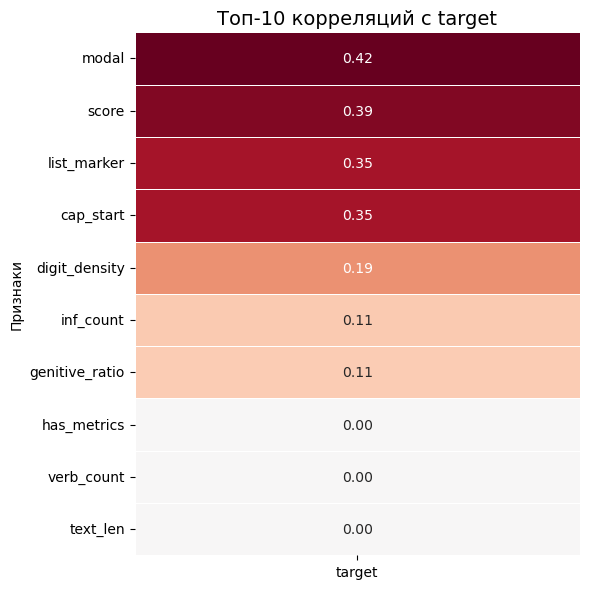

In [25]:
def plot_target_correlations(corr_series, top_n=10, figsize=(6, 6)):
    """
    Визуализирует топ-N признаков по корреляции с целевой переменной.
    
    """
    # Проверка типа входных данных
    if not isinstance(corr_series, pd.Series):
        raise TypeError('corr_series должен быть pandas.Series')
    
    # Убираю таргет
    corr_clean = corr_series.drop(corr_series.name, errors='ignore')
    
    # Проверяю, что есть достаточное количество признаков
    if len(corr_clean) == 0:
        raise ValueError('Нет признаков для отображения после удаления таргета')
    
    # Корректирую top_n
    if top_n > len(corr_clean):
        print(f'Внимание: запрошено top_n={top_n}, но доступно только {len(corr_clean)} признаков')
        top_n = len(corr_clean)
    
    # Беру топ по абсолютным значениям
    top_features = corr_clean.abs().nlargest(top_n).index
    top_correlations = corr_clean.loc[top_features]
    
    plt.figure(figsize=figsize)
    sns.heatmap(top_correlations.to_frame(), 
                annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, cbar=False, linewidths=0.5)
    
    plt.title(f'Топ-{top_n} корреляций с {corr_series.name}', fontsize=14)
    plt.ylabel('Признаки')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()
    
    return top_correlations

top_correlations = plot_target_correlations(phik_overview.target)

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

По прежнему лидирует флаг `modal`.

</div>

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> Вывод <a class="tocSkip"></a></h4>

Пройдя этап статистичекого анализа выявлю лидеров и кандидатов на выбывание.

**Лидеры** на основе статистической значимости:

- `modal`,
- `list_marker`,
- `cap_start`,
- `inf_count`,
- `digit_density`,
- `score`.

**Кандидаты** на выбывание на основе статистической значимости и корреляционного анализа:

- `verb_count`,
- `has_metrics`, 
- `all_caps`, 
- `text_len`,
- `cap_start`.

</div>

## Отбор признаков

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Финальный список признаков. Чтобы мои алгоритмы адекватно и стабильно работали подам чистый набор фич.

1. Multinomial Naive Bayes:

 - `text_mnb`

2. Logistic Regression и LGBM / HistGradientBoosting:

- `tfidf_logreg` и `svd_tree`. В них войдут из общего списка:
    - `modal`,
    - `list_marker`,
    - `inf_count`,
    - `digit_density`,
    - `score`.

</div>

In [26]:
col_mnb = ['text_mnb']
cols = [
    'score', 'modal', 'inf_count',
    'list_marker', 'digit_density'
]
num_cols = ['score', 'inf_count', 'digit_density']
cat_cols = ['modal', 'list_marker']
cols_drop = [
    'document', 'has_metrics', 'source_url', 
    'verb_count', 'genitive_ratio', 'ends_dot',
    'ends_semi', 'text_len', 'all_caps', 'cap_start',
    'target'
    ]

# Подготовка к обучению

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

На данном этапе следующий порядок действий:

- создаю выборки данных;
- для LogReg:
    - использую обработку выбросов, аномалий;
    - использую стандартизацию ;
    - создаю эмбеддинги и объединяю признаки.
- MNB - создаю эмбеддинги и объединяю признаки.
- бустинги - создаю эмбеддинги и объединяю признаки.

</div>

## Разделение данных

In [27]:
RANDOM_STATE = 654321
TEST_SIZE = 0.2

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(cols_drop, axis=1),
    data.target,
    random_state=RANDOM_STATE,
    test_size=TEST_SIZE,
    shuffle=True,
    stratify=data.target
)

## Logistic Regression

### Выбросы, аномалии, стандартизация

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Так как алгоритм минимизирует общую ошибку один далекий выброс может оттянуть линию решения на себя. А аномалии заставляют коэффициенты принимать экстремальниые значенияя, что портит интерпретируемость. Выполню это через кастомный трансформер. С помощью StandardScaler сведу признаки к единому масштабу. Если подать длину строки 300 и бинарный признак 1, модель решит, что длина в 300 раз важнее. Стандартизация уравнивает их шансы.

</div>

In [30]:
class SkipEmissionPreprocessor(BaseEstimator, TransformerMixin):
    """
    Универсальный препроцессор для обработки выбросов, пропусков в числовых
    и категориальных признаках.
    
    Класс предоставляет комплексную обработку данных включая:
    - Обработку выбросов методом IQR для числовых признаков
    - Заполнение пропусков в числовых признаках медианами
    - Заполнение пропусков в категориальных признаках модой или заданным значением
    - Гибкую настройку порогов и исключений для отдельных признаков
    - Визуализацию результатов обработки
    
    Args:
    threshold : float, optional, default=1.5
        Порог IQR по умолчанию для всех числовых признаков.
        Умножается на межквартильный размах для определения границ выбросов.
        Стандартное значение 1.5 соответствует правилу Тьюки для умеренных выбросов.
        
    custom_thresholds : dict, optional, default=None
        Словарь индивидуальных порогов для конкретных признаков.
        Формат: {feature_name: threshold}
        Пример: {'age': 2.0, 'income': 3.0}
        Если для признака задан кастомный порог, он имеет приоритет над общим threshold.
        
    handle_missing : bool, optional, default=True
        Включить ли обработку пропущенных значений.
        Если True, пропуски в числовых признаках заполняются медианой,
        в категориальных - модой или categorical_fill_value.
        
    handle_categorical : bool, optional, default=True
        Включить ли обработку категориальных признаков.
        Если False, категориальные признаки игнорируются при обработке пропусков.
        
    categorical_fill_value : str, optional, default='MISSING'
        Значение для заполнения пропусков в категориальных признаках.
        Если None, используется мода (самое частое значение) для каждого признака.
        Для категориальных типов данных значение будет добавлено в категории при необходимости.
        
    verbose : bool, optional, default=True
        Выводить ли подробную информацию о процессе обработки.
        Если False, выводится только минимальная информация о процессе.
        
    skip_features : list, optional, default=None
        Список признаков для исключения из обработки выбросов.
        Пропуски в этих признаках всё равно будут обработаны, если handle_missing=True.
        Полезно для идентификаторов, временных меток и других чувствительных признаков.
        
    numeric_features : list, optional, default=None
        Список явно указанных числовых признаков.
        Если указан, будут использоваться только эти признаки как числовые.
        Имеет приоритет над автоматическим определением типов.
        
    categorical_features : list, optional, default=None
        Список явно указанных категориальных признаков.
        Если указан, будут использоваться только эти признаки как категориальные.
        Имеет приоритет над автоматическим определением типов.
        Признаки в этом списке будут обрабатываться как категориальные,
        даже если они имеют числовой тип данных.
        
    force_categorical_types : bool, optional, default=True
        Принудительно преобразовывать ли указанные категориальные признаки 
        в категориальный тип данных (category).
        Если True, признаки из categorical_features будут преобразованы в category.
        
    Attributs:
    medians_ : dict
        Словарь с медианами числовых признаков для заполнения пропусков.
        Ключи - названия признаков, значения - вычисленные медианы.
        
    modes_ : dict
        Словарь с модами категориальных признаков для заполнения пропусков.
        Ключи - названия признаков, значения - моды или categorical_fill_value.
        
    bounds_ : dict
        Словарь с границами выбросов для числовых признаков.
        Содержит нижнюю и верхнюю границы, порог и IQR для каждого признака.
        
    all_numeric_features_ : list
        Список всех числовых признаков в данных.
        
    processed_numeric_features_ : list
        Список числовых признаков, обрабатываемых на выбросы.
        Исключает признаки из skip_features.
        
    categorical_features_ : list
        Список категориальных признаков в данных.
        
    categorical_dtypes_ : dict
        Словарь с оригинальными типами данных категориальных признаков.
        Используется для сохранения типов при преобразовании.
        
    original_numeric_features_ : list
        Список признаков, которые были определены как числовые по типу данных.
        
    original_categorical_features_ : list
        Список признаков, которые были определены как категориальные по типу данных.
    
    Notes:
    - Выбросы определяются методом IQR: Q1 - threshold*IQR, Q3 + threshold*IQR
    - Выбросы заменяются на медиану признака
    - Пропуски в числовых признаках заполняются медианой
    - Пропуски в категориальных признаках заполняются модой или заданным значением
    - Признаки в skip_features исключаются из обработки выбросов, но пропуски обрабатываются
    - Для категориальных типов данных автоматически добавляются новые категории при необходимости
    - Приоритет определения типов: explicit features > skip_features > auto-detection
    
    Warnings:
    - Порог threshold=1.5 соответствует стандартному правилу 1.5*IQR
    - Слишком низкий порог может привести к потере полезной информации
    - Слишком высокий порог может не отфильтровать настоящие выбросы
    - Обработка категориальных признаков может изменить категории в данных
    - Явное указание типов признаков имеет приоритет над автоматическим определением
    """
    
    def __init__(self, threshold=1.5, custom_thresholds=None, handle_missing=True,
                 handle_categorical=True, categorical_fill_value='MISSING',
                 verbose=True, skip_features=None, numeric_features=None,
                 categorical_features=None, force_categorical_types=True):
        self.threshold = threshold
        self.custom_thresholds = custom_thresholds or {}
        self.handle_missing = handle_missing
        self.handle_categorical = handle_categorical
        self.categorical_fill_value = categorical_fill_value
        self.verbose = verbose
        self.skip_features = skip_features or []
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.force_categorical_types = force_categorical_types
        
        # Параметры из fit
        self.medians_ = {}
        self.modes_ = {}
        self.bounds_ = {}
        self.all_numeric_features_ = []
        self.processed_numeric_features_ = []
        self.categorical_features_ = []
        self.categorical_dtypes_ = {}
        self.original_numeric_features_ = []
        self.original_categorical_features_ = []
    
    def fit(self, X, y=None):
        """
        Вычисляет параметры для преобразования на обучающих данных.
        
        Agrs:
        X : pandas.DataFrame
            Обучающие данные для вычисления параметров.
            Должен содержать числовые и/или категориальные признаки.
        y : array-like, default=None
            Целевая переменная (не используется, для совместимости с sklearn).
            
        Return:
        self : object
            Возвращает экземпляр класса.
            
        Raises:
        TypeError
            Если X не является pandas.DataFrame.
        ValueError
            Если X пустой или не содержит признаков для обработки.
            Если указанные признаки не существуют в данных.
        """
        if not isinstance(X, pd.DataFrame):
            raise TypeError('X должен быть pandas.DataFrame')
        
        if X.empty:
            raise ValueError('X не может быть пустым')
        
        # Существование указанных признаков
        all_features = set(X.columns)
        
        # Проверка numeric_features
        missing_numeric = set(self.numeric_features) - all_features
        if missing_numeric:
            raise ValueError(f'Указанные числовые признаки не существуют в данных: {missing_numeric}')
        
        # Проверка categorical_features
        missing_categorical = set(self.categorical_features) - all_features
        if missing_categorical:
            raise ValueError(f'Указанные категориальные признаки не существуют в данных: {missing_categorical}')
        
        # Проверка skip_features
        missing_skip = set(self.skip_features) - all_features
        if missing_skip:
            if self.verbose:
                print(f'Предупреждение: признаки в skip_features не существуют в данных: {missing_skip}')
        
        # Сохраняю оригинальные автоматически определенные признаки
        self.original_numeric_features_ = X.select_dtypes(include=np.number).columns.tolist()
        self.original_categorical_features_ = X.select_dtypes(
            include=['object', 'category']
        ).columns.tolist()
        
        # Определю окончательные списки признаков с учетом приоритетов
        self._determine_feature_types(X)
        
        # Сохраняю медианы всех числовых признаков для пропусков
        for feature in self.all_numeric_features_:
            self.medians_[feature] = X[feature].median()
            
            # Вычисляю границы выбросов только для не-пропущенных признаков
            if feature in self.processed_numeric_features_:
                Q1 = X[feature].quantile(0.25)
                Q3 = X[feature].quantile(0.75)
                IQR = Q3 - Q1
                
                threshold = self.custom_thresholds.get(feature, self.threshold)
                
                lower_bound = Q1 - threshold * IQR
                upper_bound = Q3 + threshold * IQR
                
                self.bounds_[feature] = {
                    'lower': lower_bound,
                    'upper': upper_bound,
                    'threshold': threshold,
                    'IQR': IQR
                }
        
        # Сохраняю моды для категориальных признаков
        if self.handle_categorical and self.categorical_features_:
            for feature in self.categorical_features_:
                if self.categorical_fill_value is None:
                    # Использую моду - самое частое значение
                    mode_values = X[feature].mode()
                    self.modes_[feature] = mode_values[0] if not mode_values.empty else 'MISSING'
                else:
                    # Использую заданное значение
                    self.modes_[feature] = self.categorical_fill_value
        
        # Минимальный вывод при verbose=False
        if not self.verbose:
            total_missing = X.isna().sum().sum()
            total_features = len(self.all_numeric_features_) + len(self.categorical_features_)
            print(f'Обработано признаков: {total_features} (пропусков: {total_missing})')
        
        return self
    
    def _determine_feature_types(self, X):
        """
        Определяет типы признаков с учетом приоритетов.
        
        Правила приоритета:
        1. Признаки из numeric_features всегда числовые
        2. Признаки из categorical_features всегда категориальные
        3. Признаки из skip_features исключаются из processed_numeric_features
        4. Остальные признаки определяются автоматически
        
        Parameters:
        X : pandas.DataFrame
            Исходные данные.
        """
        all_features = set(X.columns)
        
        # Явно указанные числовые признаки
        numeric_features_explicit = set(self.numeric_features)
        
        # Явно указанные категориальные признаки
        categorical_features_explicit = set(self.categorical_features)
        
        # Автоматически определенные числовые, кроме явных категориальных
        numeric_features_auto = (
            set(self.original_numeric_features_) - categorical_features_explicit
        )
        
        # Автоматически определенные категориальные, кроме явных числовых
        categorical_features_auto = (
            set(self.original_categorical_features_) - numeric_features_explicit
        )
        
        # Остальные признаки, неопределенные автоматически
        other_features = (
            all_features - 
            numeric_features_explicit - 
            categorical_features_explicit -
            numeric_features_auto - 
            categorical_features_auto
        )
        
        # Для остальных признаков пробую определить тип
        other_numeric = set()
        other_categorical = set()
        
        for feature in other_features:
            # Проверяю, можно ли считать числовым
            if self._could_be_numeric(X[feature]):
                other_numeric.add(feature)
            else:
                other_categorical.add(feature)
        
        # Объединяю все числовые признаки
        all_numeric = (
            numeric_features_explicit | 
            numeric_features_auto | 
            other_numeric
        )
        
        # Объединяю все категориальные признаки
        all_categorical = (
            categorical_features_explicit | 
            categorical_features_auto | 
            other_categorical
        )
        
        # Проверяю пересечения
        intersection = all_numeric & all_categorical
        if intersection:
            if self.verbose:
                print(f'Предупреждение: следующие признаки определены и как числовые, и как категориальные: {intersection}')
                print('Категориальные признаки имеют приоритет.')
            # Категориальные имеют приоритет
            all_numeric = all_numeric - intersection
        
        # Фиксирую окончательные списки
        self.all_numeric_features_ = sorted(list(all_numeric))
        self.categorical_features_ = sorted(list(all_categorical))
        
        # Определяю признаки для обработки выбросов
        self.processed_numeric_features_ = [
            col for col in self.all_numeric_features_ 
            if col not in self.skip_features
        ]
        
        # Вывожу информацию о типах
        if self.verbose:
            print(f"{'='*60}")
            print(f"{Style.BRIGHT}ОПРЕДЕЛЕНИЕ ТИПОВ ПРИЗНАКОВ:{Style.RESET_ALL}")
            print(f"{'='*60}")
            
            print(f'\n{Style.BRIGHT}Числовые признаки ({len(self.all_numeric_features_)}):{Style.RESET_ALL}')
            for i, feat in enumerate(self.all_numeric_features_, 1):
                source = []
                if feat in numeric_features_explicit:
                    source.append('явно указан')
                if feat in numeric_features_auto:
                    source.append('автоматически')
                if feat in other_numeric:
                    source.append('определён из остальных')
                print(f"  {i:2}. {feat:30} ({', '.join(source)})")
            
            if self.categorical_features_:
                print(f'\n{Style.BRIGHT}Категориальные признаки ({len(self.categorical_features_)}):{Style.RESET_ALL}')
                for i, feat in enumerate(self.categorical_features_, 1):
                    source = []
                    if feat in categorical_features_explicit:
                        source.append('явно указан')
                    if feat in categorical_features_auto:
                        source.append('автоматически')
                    if feat in other_categorical:
                        source.append('определён из остальных')
                    print(f"  {i:2}. {feat:30} ({', '.join(source)})")
            
            if self.skip_features:
                print(f'\n{Style.BRIGHT}Исключены из обработки выбросов ({len(self.skip_features)}):{Style.RESET_ALL}')
                for i, feat in enumerate(self.skip_features, 1):
                    print(f'  {i:2}. {feat}')
            
            print(f'\n{Style.BRIGHT}Итоговая статистика:{Style.RESET_ALL}')
            print(f'  Числовых признаков: {len(self.all_numeric_features_)}')
            print(f'  Категориальных признаков: {len(self.categorical_features_)}')
            print(f'  Обрабатываются выбросы: {len(self.processed_numeric_features_)}')
            print(f'  Исключено из выбросов: {len(self.skip_features)}')
    
    def _could_be_numeric(self, series):
        """
        Проверяет, можно ли считать серию числовой.
        
        Args:
        series : pandas.Series
            Серия для проверки.
            
        Return:
        bool
            True если серию можно считать числовой.
        """
        # Пропускаю пропуски
        non_null = series.dropna()
        if len(non_null) == 0:
            return True  # Пустая серия - по умолчанию числовая
        
        # Пробую преобразовать в числовой тип
        try:
            pd.to_numeric(non_null, errors='raise')
            return True
        except (ValueError, TypeError):
            return False
    
    def transform(self, X):
        """
        Применяет преобразования к данным.
        
        Args:
        X : pandas.DataFrame
            Данные для преобразования.
            Должен иметь те же признаки, что и при fit.
            
        Return:
        X_transformed : pandas.DataFrame
            Преобразованные данные с обработанными пропусками и выбросами.
            
        Raises:
        ValueError
            Если X не содержит ожидаемых признаков.
        """
        X_transformed = X.copy()
        
        # Привожу типы категориальных признаков
        #if self.force_categorical_types and self.categorical_features_:
            #for feature in self.categorical_features_:
                #if feature in X_transformed.columns:
                    # Преобразую в категориальный тип
                    #if not pd.api.types.is_categorical_dtype(X_transformed[feature]):
                        #X_transformed[feature] = pd.Categorical(X_transformed[feature])
                    # Сохраняю тип
                    #self.categorical_dtypes_[feature] = X_transformed[feature].dtype
        
        # Проверяю наличие ожидаемых признаков
        missing_features = set(self.all_numeric_features_ + self.categorical_features_) - set(X.columns)
        if missing_features:
            raise ValueError(f'Отсутствуют ожидаемые признаки: {missing_features}')
        
        # Обработка пропусков для всех числовых признаков
        if self.handle_missing:
            for feature in self.all_numeric_features_:
                if feature in X_transformed.columns:
                    X_transformed[feature] = X_transformed[feature].fillna(
                        self.medians_[feature]
                    )
        
        # Обработка пропусков в категориальных признаках
        if self.handle_categorical and self.handle_missing and self.categorical_features_:
            for feature in self.categorical_features_:
                if feature in X_transformed.columns:
                    # Для категориальных признаков нужно особое обращение
                    X_transformed[feature] = self._fill_categorical_missing(
                        X_transformed[feature], feature
                    )
        
        # Обработка выбросов только для не пропущенных признаков
        for feature in self.processed_numeric_features_:
            if feature in X_transformed.columns and feature in self.bounds_:
                bounds = self.bounds_[feature]
                mask_outliers = (
                    (X_transformed[feature] < bounds['lower']) | 
                    (X_transformed[feature] > bounds['upper'])
                )
                X_transformed.loc[mask_outliers, feature] = self.medians_[feature]
        
        # Вывод результатов
        if self.verbose:
            self._display_results_table(X)
        else:
            # Минимальный вывод
            total_missing_after = X_transformed.isna().sum().sum()
            if total_missing_after == 0:
                print('Преобразование завершено. Пропусков нет.')
            else:
                print(f'Преобразование завершено. Осталось пропусков: {total_missing_after}')
        
        return X_transformed
    
    def _fill_categorical_missing(self, series, feature_name):
        """
        Специальный метод для заполнения пропусков в категориальных признаках.
        
        Args:
        series : pandas.Series
            Серия с категориальными данными.
        feature_name : str
            Название признака.
            
        Return:
        pandas.Series
            Серия с заполненными пропусками.
        """
        fill_value = self.modes_[feature_name]
        
        # Проверяю тип данных
        if hasattr(series, 'cat'):  # Это категориальный тип
            # Если значение заполнения уже в категориях, использую его
            if fill_value in series.cat.categories:
                return series.fillna(fill_value)
            else:
                # Добавляю новую категорию и заполняю
                return series.cat.add_categories(fill_value).fillna(fill_value)
        else:
            # Для обычных object типов
            return series.fillna(fill_value)
    
    def _display_results_table(self, X):
        """
        Выводит подробную таблицу с результатами обработки.
        
        Args:
        X : pandas.DataFrame
            Исходные данные для анализа статистики.
        """
        print(f"\n{Style.BRIGHT}{Fore.CYAN}{'='*60}{Style.RESET_ALL}")
        print(f'{Style.BRIGHT}{Fore.CYAN}РЕЗУЛЬТАТЫ ПРЕДОБРАБОТКИ ДАННЫХ{Style.RESET_ALL}')
        print(f'{Style.BRIGHT}{Fore.CYAN}{"="*60}{Style.RESET_ALL}')
        
        # Статистика по пропускам до обработки
        if self.handle_missing:
            print(f'\n{Style.BRIGHT}ОБРАБОТКА ПРОПУСКОВ:{Style.RESET_ALL}')
            
            missing_info = []
            # Числовые признаки
            for feature in self.all_numeric_features_:
                if feature in X.columns:
                    missing_count = X[feature].isna().sum()
                    if missing_count > 0:
                        missing_info.append({
                            'Признак': feature,
                            'Тип': 'Числовой',
                            'Пропусков': missing_count,
                            'Процент': round(missing_count / len(X) * 100, 2),
                            'Заполнено': f'медиана ({self.medians_[feature]:.2f})'
                        })
            
            # Категориальные признаки
            if self.handle_categorical and self.categorical_features_:
                for feature in self.categorical_features_:
                    if feature in X.columns:
                        missing_count = X[feature].isna().sum()
                        if missing_count > 0:
                            fill_value = self.modes_[feature]
                            missing_info.append({
                                'Признак': feature,
                                'Тип': 'Категориальный',
                                'Пропусков': missing_count,
                                'Процент': round(missing_count / len(X) * 100, 2),
                                'Заполнено': f'"{fill_value}"'
                            })
            
            if missing_info:
                missing_df = pd.DataFrame(missing_info)
                display(missing_df.set_index('Признак'))
            else:
                print('  Пропусков не обнаружено')
        
        # Статистика по выбросам
        if self.bounds_:
            print(f'\n{Style.BRIGHT}ОБРАБОТКА ВЫБРОСОВ (IQR метод):{Style.RESET_ALL}')
            
            outliers_info = []
            for feature in self.processed_numeric_features_:
                if feature in X.columns and feature in self.bounds_:
                    bounds = self.bounds_[feature]
                    lower_outliers = (X[feature] < bounds['lower']).sum()
                    upper_outliers = (X[feature] > bounds['upper']).sum()
                    total_outliers = lower_outliers + upper_outliers
                    
                    if total_outliers > 0:
                        outliers_info.append({
                            'Признак': feature,
                            'Порог': bounds['threshold'],
                            'Нижняя граница': round(bounds['lower'], 2),
                            'Верхняя граница': round(bounds['upper'], 2),
                            'Выбросов': total_outliers,
                            'Процент': round(total_outliers / len(X) * 100, 2),
                            'Заменено на': f'медиана ({self.medians_[feature]:.2f})'
                        })
            
            if outliers_info:
                outliers_df = pd.DataFrame(outliers_info)
                display(outliers_df.set_index('Признак'))
            else:
                print('  Выбросов не обнаружено')
        
        # Показываем пропущенные признаки
        if self.skip_features:
            print(f'\n{Style.BRIGHT}{Fore.YELLOW}ПРИЗНАКИ БЕЗ ОБРАБОТКИ ВЫБРОСОВ:{Style.RESET_ALL}')
            for feature in self.skip_features:
                if feature in self.all_numeric_features_:
                    print(f"  - {feature}")
        
        # Общая статистика
        print(f'\n{Style.BRIGHT}ОБЩАЯ СТАТИСТИКА:{Style.RESET_ALL}')
        print(f'  Обработано числовых признаков: {len(self.processed_numeric_features_)}')
        if self.handle_categorical and self.categorical_features_:
            print(f'  Обработано категориальных признаков: {len(self.categorical_features_)}')
        print(f'  Исключено из обработки выбросов: {len(self.skip_features)}')
    
    def get_feature_stats(self):
        """
        Возвращает статистику по признакам.
        
        Return:
        dict
            Словарь с медианами, модами и границами выбросов.
            Структура:
            {
                'medians': {feature: median_value},
                'modes': {feature: mode_value},
                'bounds': {feature: {'lower': lb, 'upper': ub, 'threshold': t}},
                'numeric_features': list,
                'categorical_features': list,
                'original_numeric': list,
                'original_categorical': list
            }
        """
        return {
            'medians': self.medians_,
            'modes': self.modes_,
            'bounds': self.bounds_,
            'numeric_features': self.all_numeric_features_,
            'categorical_features': self.categorical_features_,
            'original_numeric': self.original_numeric_features_,
            'original_categorical': self.original_categorical_features_
        }

In [31]:
X_train_logreg = X_train[cols].copy()
X_test_logreg = X_test[cols].copy()

In [32]:
pipe_pre = Pipeline([
    ('skip_emission_pre', SkipEmissionPreprocessor(
        threshold=1.5,
        handle_missing=True,
        handle_categorical=True,
        categorical_fill_value='неизвестно',
        verbose=True,
        numeric_features=[
            'score', 'inf_count', 'digit_density'
        ],
        categorical_features=[
            'modal', 'list_marker'
        ],
        #skip_features=['lemma_text']
    ))
])

print('\nТренировочная выборка')
X_train_logreg = pipe_pre.fit_transform(X_train_logreg)
print('\nТестовая выборка')
X_test_logreg = pipe_pre.transform(X_test_logreg)


Тренировочная выборка
ОПРЕДЕЛЕНИЕ ТИПОВ ПРИЗНАКОВ:

Числовые признаки (3):
   1. digit_density                  (явно указан, автоматически)
   2. inf_count                      (явно указан, автоматически)
   3. score                          (явно указан, автоматически)

Категориальные признаки (2):
   1. list_marker                    (явно указан)
   2. modal                          (явно указан)

Итоговая статистика:
  Числовых признаков: 3
  Категориальных признаков: 2
  Обрабатываются выбросы: 3
  Исключено из выбросов: 0

РЕЗУЛЬТАТЫ ПРЕДОБРАБОТКИ ДАННЫХ

ОБРАБОТКА ПРОПУСКОВ:
  Пропусков не обнаружено

ОБРАБОТКА ВЫБРОСОВ (IQR метод):


,Порог,Нижняя граница,Верхняя граница,Выбросов,Процент,Заменено на
Признак,,,,,,
digit_density,1.5,-0.04,0.08,15,4.55,медиана (0.01)
inf_count,1.5,-1.50,2.50,2,0.61,медиана (1.00)
score,1.5,0.50,4.50,57,17.27,медиана (2.00)



ОБЩАЯ СТАТИСТИКА:
  Обработано числовых признаков: 3
  Обработано категориальных признаков: 2
  Исключено из обработки выбросов: 0

Тестовая выборка

РЕЗУЛЬТАТЫ ПРЕДОБРАБОТКИ ДАННЫХ

ОБРАБОТКА ПРОПУСКОВ:
  Пропусков не обнаружено

ОБРАБОТКА ВЫБРОСОВ (IQR метод):


,Порог,Нижняя граница,Верхняя граница,Выбросов,Процент,Заменено на
Признак,,,,,,
digit_density,1.5,-0.04,0.08,8,9.64,медиана (0.01)
score,1.5,0.50,4.50,12,14.46,медиана (2.00)



ОБЩАЯ СТАТИСТИКА:
  Обработано числовых признаков: 3
  Обработано категориальных признаков: 2
  Исключено из обработки выбросов: 0


### Стандартизация

In [33]:
scaler = StandardScaler()
X_train_logreg[num_cols] = scaler.fit_transform(X_train_logreg[num_cols])
X_test_logreg[num_cols] = scaler.transform(X_test_logreg[num_cols])

### Векторизация и объединение

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Подготовлю текстовое ядро. По параметрам векторизатора не беру все слова подряд, так как для ГОСТов важны устойчивые словосочетания.

- ngram_range=(1, 2). Беру и отдельные леммы и пары слов;
- min_df=3. Отсекаю опечатки и слишком редкие слова, которые встретились всего в 1-2 предложениях. Это защитит от переобучения.
- max_df=0.9. Убираю слишком частые слова, которые есть почти в каждом предложении, они не несут смысла для классификации.

Склеивание с числовыми признаками. У меня есть разреженная матрица слов и плотная таблица с признаками. Приклеиваю к каждой строке TF-IDF весов стандартизированные признаки. И сохраню имена признаков.

</div>

In [34]:
tfidf = TfidfVectorizer(
    min_df=3, 
    max_df=0.9, 
    ngram_range=(1, 2),
    max_features=5000
)

X_train_logreg_tfidf = tfidf.fit_transform(X_train['lemma_text'])
X_test_logreg_tfidf = tfidf.transform(X_test['lemma_text'])

X_train_logreg_tfidf = hstack([X_train_logreg_tfidf, X_train_logreg.values])
X_test_logreg_tfidf = hstack([X_test_logreg_tfidf, X_test_logreg.values])

feature_names_logreg = list(tfidf.get_feature_names_out()) + cols

print(f'Размерность вектора признаков: {X_train_logreg_tfidf.shape[1]}')
print(f'Доля разреженности: {X_train_logreg_tfidf.nnz / (X_train_logreg_tfidf.shape[0] * X_train_logreg_tfidf.shape[1]):.2f}')


Размерность вектора признаков: 799
Доля разреженности: 0.03


## Multinomial Naive Bayes

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Здесь логика векторизации принципиально иная, не использую склейку через hstack, а работаю с гибридным текстом, который подготовил на этапе **Этап 9.3.2**. Использую CountVectorizer с параметрами:

- min_df=2;
- ngram_range=(1, 1). Поскольку внедрил синтетические токены, биграммы могут создать лишний шум.

</div>

In [35]:
c_vec = CountVectorizer(min_df=2, ngram_range=(1, 1))
X_train_mnb_vec = c_vec.fit_transform(X_train['text_mnb'])
X_test_mnb_vec = c_vec.transform(X_test['text_mnb'])

## LGBM / HistGradientBoosting

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Для деревянных стратегия меняется, перейду к плотным векторам:

- текстовое ядро. Утрамбую смысл через TruncatedSVD до 50 колонок;
- без стандартизации. Деревьям не важна размерность, они сами найдут оптимальные пороги разделения.

</div>

In [36]:
svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)

X_train_tree_tfidf_svd = svd.fit_transform(X_train_logreg_tfidf)
X_test_tree_tfidf_svd = svd.transform(X_test_logreg_tfidf)

X_train_tree_tfidf_svd = np.hstack([X_train_tree_tfidf_svd, X_train[cols].values])
X_test_tree_tfidf_svd = np.hstack([X_test_tree_tfidf_svd, X_test[cols].values])


# Обучение

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

В качестве baseline я использую следующие алгоритмы:

- Multinomial Naive Bayes,
- LinearRegresion,
- LGBMClassifier,
- HistGradientBoosting.

При выборе метрики оценки опираюсь на следующее рассуждение.

Допустим при сценарии использования финальной модели как **Ассистент для инженера**, в котором он предложит 10 лишних пунктов (FP) не являющихся требованием, это небольшое неудобство. Но, если ассистент промолчал о критически важном требовании (FN), это дискредитирует всю систему и делает её опасной. Ведь пропущенное требование, это прямая угроза безопасности. По этому для оценки буду использовать метрику F2-score , чтобы минимизировать ложно-негативные срабатывания (FN). 

$F_{\beta}$-мера с коэффициентом $\beta=2$, это стандартный прием, когда полнота в 2 раза важнее точности. Формула $F_2$ выглядит так:  
$$F_2 = (1 + 2^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(2^2 \cdot \text{Precision}) + \text{Recall}}$$

$F_2$ штрафует за низкий Precision. Получается с этой метрикой результат не превращается в помойку. В идеале цель Recall > 0.90. Но в то же время $F_2$, это судья, который контролирует, чтобы цена высокого Recall не была слишком велика. Буду ориентироваться на $F_2$, но поглядывать на Recall. Если Recall высокий, а $F_2$ низкий - значит, алгоритм слишком болтлив и бесполезен.

Так же учту дисбаланс классов и использую регуляризацию при обучении.

</div>

## Baseline

In [37]:
data_bundles = {
    'MultinomialNaiveBayes': (X_train_mnb_vec, X_test_mnb_vec),
    'LogisticRegression': (X_train_logreg_tfidf, X_test_logreg_tfidf),
    'LightGBM': (X_train_tree_tfidf_svd, X_test_tree_tfidf_svd),
    'HistGradientBoosting': (X_train_tree_tfidf_svd, X_test_tree_tfidf_svd)
}

models = {
    'MultinomialNaiveBayes': MultinomialNB(
        alpha=1.0
    ),
    'LogisticRegression': LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        solver='liblinear'
    ),
    'LightGBM': LGBMClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        max_depth=3, 
        n_estimators=100,
        verbose=-1
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        class_weight='balanced',
        max_depth=3,
        random_state=RANDOM_STATE
        )
}

f2_scorer = make_scorer(fbeta_score, beta=2)
scoring = {
    'F2_score': f2_scorer,
    'Precision': 'precision',
    'Recall': 'recall',
    'ROC_AUC': 'roc_auc'
}

In [38]:
def baseline(
        models_dict, data_bundles, y_train, 
        n_splits, n_repeats, scorers
        ):
    
    final_results = []
    rkf = RepeatedStratifiedKFold(
        n_splits=n_splits, 
        n_repeats=n_repeats, 
        random_state=RANDOM_STATE
    )
    for name, model in models_dict.items():
        X_data = data_bundles[name][0] 
        cv = cross_validate(
            model, 
            X_data, 
            y_train, 
            cv=rkf, 
            scoring=scorers, 
            n_jobs=-1,
            return_train_score=False
        )
        
        res_entry = {
            'Модель': name,
            'Время валидации, сек.': cv['fit_time'].mean().round(2)
        }
        
        for metric_name in scorers.keys():
            # Названия в словаре cv имеют префикс test_
            mean_val = cv[f'test_{metric_name}'].mean()
            res_entry[metric_name] = mean_val.round(2)
        
        final_results.append(res_entry)

    report = pd.DataFrame(final_results)
    report = report.sort_values(by='F2_score', ascending=False).set_index('Модель')
    
    return report

In [39]:
baseline(
    models, data_bundles, y_train, 
    5, 3, scoring
)

/home/vitalii/anaconda3/envs/ds/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/vitalii/anaconda3/envs/ds/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/vitalii/anaconda3/envs/ds/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

,"Время валидации, сек.",F2_score,Precision,Recall,ROC_AUC
Модель,,,,,
MultinomialNaiveBayes,0.00,0.67,0.59,0.69,0.76
LogisticRegression,0.00,0.65,0.59,0.68,0.79
LightGBM,0.29,0.56,0.58,0.55,0.75
HistGradientBoosting,0.08,0.55,0.59,0.54,0.74


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Очевидный лидер MultinomialNB. Лучший показатель $F_2$. Алгоритм выучил синтетические токены и эффективнее находит требования, пропуская меньше всего важных пунктов.

LogisticRegression второе место. Имеет самый высокий ROC_AUC. Это значит, что он качественнее всех ранжирует предложения по вероятности.

Бустинги провалились по Recall. Они слишком осторожничают, пропуская почти половину реальных требований. На маленькой выборке им просто не хватило примеров для построения глубоких связей.

Далее продолжу с MultinomialNB или LogisticRegression.

</div>

## Подбор гиперпараметров

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

В качестве инструмента для поиска лучших гиперпараметров использую Optuna. 

Для MultinomialNB основная магия скрыта не в самом алгоритме, а в векторизаторе. Поэтому в Optuna нужно оптимизировать CountVectorizer.

Для LogisticRegression параметры буду подбирать так же, начиная с векторизатора и постепенно для алгоритма.

</div>

### MultinomialNB

In [40]:
def objective_mnb(trial):
    cv_params = {
        'ngram_range': trial.suggest_categorical('nb_ngram', [(1, 1), (1, 2)]),
        'min_df': trial.suggest_int('nb_min_df', 2, 3)
    }
    
    nb_params = {
        'alpha': trial.suggest_float('alpha', 0.1, 5, log=True),
        'fit_prior': trial.suggest_categorical('fit_prior', [True, False])
    }

    model = Pipeline([
        ('cv', CountVectorizer(**cv_params)),
        ('nb', MultinomialNB(**nb_params))
    ])

    rkf = RepeatedStratifiedKFold(
        n_splits=5, 
        n_repeats=3, 
        random_state=RANDOM_STATE
    )

    cv = cross_validate(
            model, 
            X_train['text_mnb'],
            y_train, 
            cv=rkf, 
            scoring=f2_scorer, 
            n_jobs=-1,
            return_train_score=False
        )

    return cv['test_score'].mean().round(2)

In [41]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_mnb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE) 
)
study_mnb.optimize(objective_mnb, n_trials=150, show_progress_bar=True)

Best trial: 20. Best value: 0.7: 100%|██████████| 150/150 [00:04<00:00, 32.76it/s]


In [42]:

best_params_mnb = study_mnb.best_params
print('Лучшие параметры:', study_mnb.best_params)
print('Лучший результат F2:', study_mnb.best_value)

Лучшие параметры: {'nb_ngram': (1, 1), 'nb_min_df': 3, 'alpha': 0.906412578363329, 'fit_prior': False}
Лучший результат F2: 0.7


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Кратко о результате. Победа простоты nb_ngram: (1, 1) и жесткая фильтрация шума nb_min_df: 3 в векторайзере. Высокая чувствительность у MultinomialNB - alpha: 0.9. Метрика не впечатляет F2: 0.7, но все же надо понимать, что данных мало для построения сильных паттернов.

</div>

### LogisticRegression

In [43]:
if 'lemma_text' not in X_train_logreg.columns:
    X_train_logreg.insert(0, 'lemma_text', X_train['lemma_text'])

In [44]:
def objective_logreg(trial):
    tfidf_params = {
        'ngram_range': trial.suggest_categorical('ngram_range', [(1, 1), (1, 2), (1, 3)]),
        'min_df': trial.suggest_int('min_df', 10, 20),
        'max_df': trial.suggest_float('max_df', 0.6, 0.99),
        'use_idf': trial.suggest_categorical('use_idf', [True, False]),
        'max_features': trial.suggest_int('max_features', 3000, 8000, step=250)
    }

    logit_params = {
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'solver': 'liblinear', # надежен для малых данных и L1/L2
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2'])
    }

    preprocessor = ColumnTransformer([
        ('tfidf', TfidfVectorizer(**tfidf_params), 'lemma_text')
    ], remainder='passthrough')

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(**logit_params, random_state=RANDOM_STATE))
    ])

    rkf = RepeatedStratifiedKFold(
        n_splits=5, 
        n_repeats=3, 
        random_state=RANDOM_STATE
    )

    cv = cross_validate(
            model, 
            X_train_logreg,
            y_train, 
            cv=rkf, 
            scoring=f2_scorer, 
            n_jobs=-1,
            return_train_score=False
        )

    return cv['test_score'].mean().round(2)

In [45]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_logreg = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE) 
)
study_logreg.optimize(objective_logreg, n_trials=100, show_progress_bar=True)

Best trial: 72. Best value: 0.71: 100%|██████████| 100/100 [00:06<00:00, 15.81it/s]


In [46]:
best_params_logreg = study_logreg.best_params
print('Лучшие параметры:', study_logreg.best_params)
print('Лучший результат F2:', study_logreg.best_value)

Лучшие параметры: {'ngram_range': (1, 3), 'min_df': 14, 'max_df': 0.7596479354913508, 'use_idf': False, 'max_features': 4750, 'C': 0.0013112140749666824, 'class_weight': 'balanced', 'penalty': 'l2'}
Лучший результат F2: 0.71


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h4>

Кратко о результате. Агрессивная фильтрация шума min_df: 14. Неожиданный и важный параметр. Модель игнорирует любые слова, которые встречаются реже 14 раз. Для моего объема данных это означает экстремальную очистку словаря от редких терминов. Максимальное сглаживание C: 0.001, здесь жесткое подавление весов. Модель крайне осторожна и не дает ни одному слову или признаку стать доминирующим. Структура не самая простая ngram_range: (1, 3)

</div>

# Тестировние

## MultinomialNB

<Figure size 800x600 with 0 Axes>

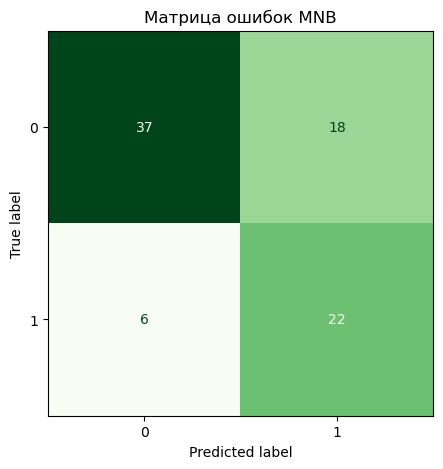

              precision    recall  f1-score   support

           0       0.86      0.67      0.76        55
           1       0.55      0.79      0.65        28

    accuracy                           0.71        83
   macro avg       0.71      0.73      0.70        83
weighted avg       0.76      0.71      0.72        83

F2-score на тесте: 0.72


In [47]:
final_mnb = Pipeline([
    ('cv', CountVectorizer(
        ngram_range=best_params_mnb['nb_ngram'], 
        min_df=best_params_mnb['nb_min_df']
    )),
    ('nb', MultinomialNB(
        alpha=best_params_mnb['alpha'], 
        fit_prior=best_params_mnb['fit_prior']
    ))
])

final_mnb.fit(X_train['text_mnb'], y_train)
y_pred_mnb = final_mnb.predict(X_test['text_mnb'])
y_probs_mnb = final_mnb.predict_proba(X_test['text_mnb'])[:, 1]
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
disp_mnb = ConfusionMatrixDisplay(confusion_matrix=cm_mnb, display_labels=['0', '1'])

plt.figure(figsize=(8, 6))
disp_mnb.plot(cmap='Greens', values_format='d', colorbar=False)
plt.title('Матрица ошибок MNB')
plt.show()

print(classification_report(y_test, y_pred_mnb))
f2_mnb = fbeta_score(y_test, y_pred_mnb, beta=2)
print(f'F2-score на тесте: {f2_mnb:.2f}')

## LogisticRegression

In [48]:
if 'lemma_text' not in X_test_logreg.columns:
    X_test_logreg.insert(0, 'lemma_text', X_test['lemma_text'])

<Figure size 800x600 with 0 Axes>

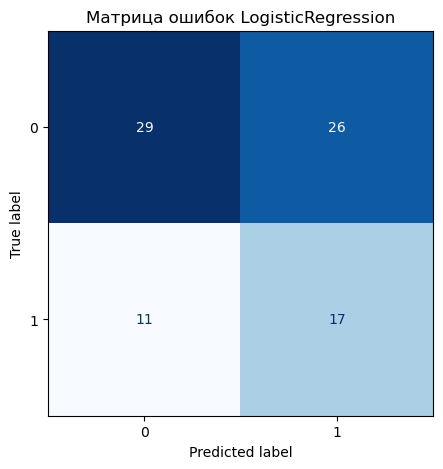

              precision    recall  f1-score   support

           0       0.72      0.53      0.61        55
           1       0.40      0.61      0.48        28

    accuracy                           0.55        83
   macro avg       0.56      0.57      0.54        83
weighted avg       0.61      0.55      0.57        83

F2-score на тесте: 0.55


In [49]:
final_logreg = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('tfidf', TfidfVectorizer(
            ngram_range=best_params_logreg['ngram_range'],
            min_df=best_params_logreg['min_df'],
            max_df=best_params_logreg['max_df'],
            use_idf=best_params_logreg['use_idf'],
            max_features=best_params_logreg['max_features']
        ), 'lemma_text')
    ], remainder='passthrough')),
    ('clf', LogisticRegression(
        C=best_params_logreg['C'], 
        class_weight=best_params_logreg['class_weight'], 
        penalty=best_params_logreg['penalty'],
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

final_logreg.fit(X_train_logreg, y_train)
y_pred_logreg = final_logreg.predict(X_test_logreg)
y_probs_logreg = final_logreg.predict_proba(X_test_logreg)[:, 1]

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
disp_cm_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=['0', '1'])

plt.figure(figsize=(8, 6))
disp_cm_logreg.plot(cmap='Blues', values_format='d', colorbar=False)
plt.title('Матрица ошибок LogisticRegression')
plt.show()

print(classification_report(y_test, y_pred_logreg))
f2_logreg = fbeta_score(y_test, y_pred_logreg, beta=2)
print(f'F2-score на тесте: {f2_logreg:.2f}')


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> Вывод <a class="tocSkip"></a></h4>

MultinomialNB уверенно вырывается вперед с неплохим Recall по целевому классу в 0.79 и F2 0.72.

</div>

## Важность признаков

#### MultinomialNB

In [50]:
feature_names_mnb = final_mnb.named_steps['cv'].get_feature_names_out()

# Важность, разница лог-вероятностей между классами
# 2 класса, беру разность, это покажет, насколько признак различает классы.
log_probs = final_mnb.named_steps['nb'].feature_log_prob_
if log_probs.shape[0] == 2:
    weights = log_probs[1] - log_probs[0]
else:
    # Стандартное отклонение вероятностей как мера важности
    weights = log_probs.std(axis=0)

feature_importance_mnb = pd.DataFrame({
    'Признак': feature_names_mnb,
    'Важность': abs(weights)  # модуль, чтобы увидеть общую значимость
}).sort_values('Важность', ascending=False).set_index('Признак')

print(f'{Style.BRIGHT}{Fore.CYAN}ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ{Style.RESET_ALL}')
feature_importance_mnb['Важность PCT'] = (
    feature_importance_mnb['Важность'] / feature_importance_mnb['Важность'].sum() * 100
)
display(feature_importance_mnb.head(10))

zero_imp_mnb = len(feature_importance_mnb[feature_importance_mnb['Важность'] == 0])
prs_imp_5_mnb = feature_importance_mnb['Важность PCT'].head(5).sum()
prs_imp_10_mnb = feature_importance_mnb['Важность PCT'].head(10).sum()

print(f'{Style.BRIGHT}{Fore.CYAN}\nСТАТИСТИКА{Style.RESET_ALL}')
print(f'Всего признаков: {len(feature_importance_mnb)}')
print(f'Признаки с нулевой важностью: {zero_imp_mnb}')
print(f'Топ-5 признаков объясняют: {prs_imp_5_mnb:.2f}% важности')
print(f'Топ-10 признаков объясняют: {prs_imp_10_mnb:.2f}% важности')

ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ


,Важность,Важность PCT
Признак,,
арматура,2.676444,0.759075
фактор,2.626674,0.744959
точка,2.520033,0.714714
аппарат,2.492583,0.706929
контейнер,2.477587,0.702676
пена,2.369893,0.672133
частота,2.334537,0.662105
эвакуация,2.219250,0.629408
турбулизация,2.219250,0.629408



СТАТИСТИКА
Всего признаков: 512
Признаки с нулевой важностью: 0
Топ-5 признаков объясняют: 3.63% важности
Топ-10 признаков объясняют: 6.84% важности


#### LogisticRegression

In [51]:
tfidf_features = final_logreg.named_steps['preprocessor'].named_transformers_['tfidf'].get_feature_names_out()
num_cols_logreg = [col for col in X_train_logreg.columns if col != 'lemma_text']
all_feature_names = list(tfidf_features) + num_cols_logreg

weights = final_logreg.named_steps['clf'].coef_[0]

feature_importance_logreg = pd.DataFrame({
    'Признак': all_feature_names,
    'Важность': abs(weights)
}).sort_values('Важность', ascending=False).set_index('Признак')
print(f'{Style.BRIGHT}{Fore.CYAN}ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ{Style.RESET_ALL}')
feature_importance_logreg['Важность PCT'] = (
    feature_importance_logreg['Важность'] / feature_importance_logreg['Важность'].sum() * 100
)
display(feature_importance_logreg.head(10))

zero_imp_logreg = len(feature_importance_logreg[feature_importance_logreg['Важность'] == 0])
prs_imp_5_logreg = feature_importance_logreg['Важность PCT'].head(5).sum()
prs_imp_10_logreg = feature_importance_logreg['Важность PCT'].head(10).sum()

print(f'{Style.BRIGHT}{Fore.CYAN}\nСТАТИСТИКА{Style.RESET_ALL}')
print(f'Всего признаков: {len(feature_importance_logreg)}')
print(f'Признаки с нулевой важностью: {zero_imp_logreg}')
print(f'Топ-5 признаков объясняют: {prs_imp_5_logreg:.2f}% важности')
print(f'Топ-10 признаков объясняют: {prs_imp_10_logreg:.2f}% важности')

ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ


,Важность,Важность PCT
Признак,,
score,0.041593,13.668942
inf_count,0.033967,11.162764
digit_density,0.033419,10.982694
modal,0.030585,10.051342
list_marker,0.019083,6.271441
должный,0.008184,2.689603
устройство,0.007581,2.491266
не,0.007450,2.448309
при,0.006963,2.288252



СТАТИСТИКА
Всего признаков: 86
Признаки с нулевой важностью: 0
Топ-5 признаков объясняют: 52.14% важности
Топ-10 признаков объясняют: 63.43% важности


## Сравнение предсказаний

In [52]:
prob_logreg = final_logreg.predict_proba(X_test_logreg)[:, 1]
prob_mnb = final_mnb.predict_proba(X_test['text_mnb'])[:, 1]
results_comparison = pd.DataFrame({
    'text': X_test['text'].values,
    'target': y_test.values,
    'prob_logreg': prob_logreg.round(3),
    'prob_mnb': prob_mnb.round(3)
})

display(results_comparison[abs(results_comparison['prob_logreg'] - results_comparison['prob_mnb']) > 0.4].head(10))

,text,target,prob_logreg,prob_mnb
0,Определение кратности пены проводят одним из следующих способов: - взвешиванием образца пены (7.11.2.1) ; - взвешиванием образцов пены и раствора (7.11.2.2) ; - измерением объема выпадающего раствора (7.11.2.3).,0,0.520,1.000
1,Общие требования ГОСТ 12.1.005-88 Система стандартов безопасности труда.,0,0.472,0.007
2,"Температура дуги при сварке и резке достигает 4000 °C, поэтому дуга является источником зажигания всех горючих веществ.",0,0.480,0.000
3,"7.4.2 Температура, регистрируемая термопарой Т2 в период с 10-й по 20-ю минуты калибровки испытательной установки, должна быть не менее 600 °C.",0,0.522,0.999
5,Значение давления испытательной среды устанавливают не менее рабочего давления на вводе в устройство.,1,0.499,0.999
6,"Вероятность положительного исхода опыта (воспламенения, появления дыма или достижения критической температуры) определяется после проведения лабораторных испытаний в условиях равенства ; , (155) где - число опытов с положительным исходом; - число опытов.",0,0.494,0.002
7,"Для этого готовят образцы раствора пенообразователя объемом 100 мл в трех концентрациях: номинальной концентрации, номинальной концентрации плюс один (или два) процента, номинальной концентрации минус один (или два) процента.",1,0.472,0.999
9,"Пожарную опасность конструкции характеризуют: - наличием теплового эффекта (но не его значением) от горения материалов образца, который выражается в превышении температуры в тепловой камере по сравнению с верхней допустимой границей температурного режима, установленного в 7.4 ; - наличием пламенного горения газов, выделяющихся при термическом разложении материалов образца, продолжительностью более 5 с; - наличием горящего расплава при продолжительности его горения более 5 с; - размером повре...",1,0.480,0.000
10,При этом способ установки контейнера на цилиндр должен исключать возможность вытекания жидкости из контейнера за пределы мерного цилиндра.,1,0.511,0.999
11,Из проб неоднородных материалов готовят не менее трех усредненных образцов путем измельчения не менее трех проб до порошкообразного состояния и тщательного перемешивания.,1,0.499,0.901


<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> Вывод <a class="tocSkip"></a></h4>

Если вкратце, создал двух разных экспертов - скептика и фанатика.

У LogisticRegression нет определенности, все вероятности крутятся вокруг 0.47-0.52. Скорее всего это результат жесткой регуляризации.

MultinomialNB - максималист. Либо 0.999, либо 0.000. Он правильно определил 4 требования из 5.

Касательно Recall - MultinomialNB лидирует. В строках 5, 7, 10, 11 там, где LogisticRegression зависла на пороге 0.49 MultinomialNB уверенно забирает эти требования. Для F2-score, это хорошо, он практически не пропускает требования.

По ошибкам. MultinomialNB выдал 0.999 на то, что не является требованием. Потому что там есть слова проводить, должна быть и цифры. Для него это маркет требования. LogisticRegression в строках 1, 2, 6 отлично отработала шум, в то время как MultinomialNB тоже был уверен, но LogisticRegression оказалась чуть ближе к истине.

Интересный случай в строке 9. Сложное, длинное требование с перечислением. Обе модели промахнулись. Для них это слишком много текста, где сигнал «характеризуют» размылся. Это возможная зона роста для расширения датасета.

</div>

# Проблемы и возможное развитие

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> На заметку <a class="tocSkip"></a></h3>

**Проблемы**

- дисбаланс,
- мало данных,
- переобучение LogisticRegression.

**Развитие**

- расширить датасет,
- отказаться от TF-IDF в пользу natasha или трансформеров,
- использовать ансамбль моделей.

</div>

# Заключение

<div style="border: 5px ridge #7FFFD4 !important; padding: 30px; border-radius: 15px; box-sizing: border-box;">
    <h3 style="margin: 10;"> Вывод <a class="tocSkip"></a></h4>

Результат по сути не приемлемый. Инженерные фичи работают, но для адекватной метрики нужно расширять датасет. С таким количеством строк простые модели побеждают сложные. MultinomialNB определенно лидирует в этом исследовании и уверенно вырывается вперед на тесте с неплохим Recall по целевому классу в 0.79 и F2 0.72. LogisticRegression явно переобучилась, разрыв между тренировочной и тестовой метриками 0.17. 

</div>